# Mock Data Vector with Optical Selection Effects

Forward model for a Buzzard DES Y3 cluster mock on the **DES Y1 binning**
($\lambda \in \{20, 30, 45, 60, \infty\}$,
 $z \in \{0.20, 0.35, 0.50, 0.65\}$) but exclude the Buzzard $0.33 \le z \le 0.37$ simulation-box seam, and:

1. Intrinsic mass-richness relation (Costanzi+2026, Eq. 15;
   DES-Y1 NC+3 $\times$ 2pt best fit).
2. Projection $\lambda_\mathrm{true} \to \lambda_\mathrm{obs}$ via the
   Costanzi+2019 Eq. 6 mixture (Gaussian core + EMG projection tail).
3. **Two parallel constructions** of the lensing data vector:
   - **Analytical** (Matteo / C26 Eq. C1): bin on the C19 sampler
     $(\lambda^\mathrm{ob}, z^\mathrm{ob})$ and apply a fitting-function
     $\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R)$ to the stacked
     $\Delta\Sigma$.
   - **Empirical** (Heidi / mass-matched ratio): bin on the catalog
     redMaPPer outputs $(\texttt{LAMBDA\_CHISQ}, \texttt{Z\_LAMBDA})$
     and divide by a $(\log M, z_\mathrm{true})$-matched random
     reference, with bootstrap error bands.

Outputs (see Sec.9):

- $N(\lambda^\mathrm{ob}, z^\mathrm{ob})$ binned number counts (forward
  model side).
- Per-bin tangential shear and selection-bias ratio from **both** routes
  (saved separately in `output/MockDataVector.npz`).
- DES Y1 measured boost factor + final mock-observed shears
- Covariance Matrice for number count, shear and boost factor.

In [1]:
# Cap BLAS threads BEFORE numpy/sklearn import: Perlmutter login nodes have more CPUs than OpenBLAS was built for (256-thread limit), and KMeans in the §8.3 jackknife cell would otherwise segfault.
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS',      '1')
os.environ.setdefault('OMP_NUM_THREADS',      '1')

import sys
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import fitsio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator
from scipy.special import erfc
from astropy.table import Table, join
from astropy.cosmology import FlatLambdaCDM

from fileLoc import FileLocs
import radial_bins_phys_mpc as rbp

matplotlib.rc('xtick', labelsize=16, top=True, direction='in')
matplotlib.rc('ytick', labelsize=16, right=True, direction='in')
matplotlib.rc('axes', linewidth=1, labelsize=16)

## 1. Inputs

In [2]:
# --- Cosmology: same as the Buzzard simulation (arXiv:1901.02401v1) --------------
cosmo0 = FlatLambdaCDM(H0=70, Om0=0.286, Ob0=0.046, Tcmb0=2.725)

# --- Mass-richness / HOD parameters (Costanzi Eq. 15, DES-Y1 best fit).
# These are hard-coded inside costanzi_selection.py.
from costanzi_selection import (
    M_MIN, ALPHA, M_1, M_PIVOT, SIGM_INTR, EPSI, PIVOT_Z0,
    l_sat, l_tr, sig_intr, pltr_M,
    sample_lambda_true, sample_lambda_obs, projection_params,
    load_prj_interpolators, load_prj_posterior_mean,
)
print('DES-Y1 params: log10 M_min=%.4f  alpha=%.4f  log10 M_1=%.4f  '
      'sig_intr=%.4f  eps=%.4f  z_piv=%.4f'
      % (np.log10(M_MIN), ALPHA, np.log10(M_1),
         SIGM_INTR, EPSI, PIVOT_Z0))

# --- Projection-param file: posterior-mean collapse.
PRJ_FILE = os.path.join(os.getcwd(), 'data',
                        'prj_params_DESY3_lss_lin_dep_getdist_v1.txt')
PRJ_INTERP = load_prj_posterior_mean(PRJ_FILE)

# --- Halo-selection cuts ---------------------------------------------
ZMIN, ZMAX, LOGM_MIN = 0.2, 0.65, 13.0

# --- DES Y1 cluster binning (Costanzi+2019, McClintock+2019) ---------
# 4 richness bins: [20, 30), [30, 45), [45, 60), [60, inf)  (capped at 500)
# 3 photo-z bins:  [0.20, 0.33), [0.37, 0.50), [0.50, 0.65)
# (z0 upper edge moved 0.35 -> 0.33 and z1 lower edge moved 0.35 -> 0.37 to skip the Buzzard 0.33 <= z < 0.37 box-junction seam, which was excluded at halo-load time.)
LBDBINS   = np.array([20, 30, 45, 60, 500])
ZMIN_LIST = np.array([0.20, 0.37, 0.50])
ZMAX_LIST = np.array([0.33, 0.50, 0.65])

RNG = np.random.default_rng(seed=42)

DES-Y1 params: log10 M_min=11.3853  alpha=0.8587  log10 M_1=12.6964  sig_intr=0.1809  eps=0.2839  z_piv=0.4544


## 2. Load halo catalogue and $\Delta\Sigma$ profiles

Same selection as `0-MakeMock.ipynb`: `pid == -1`, $0 \le \cos i \le 1$,
drop the $0.33 \le z \le 0.37$ simulation-box seam, then require
$0.2 \le z \le 0.65$ and $\log M_\mathrm{vir} \ge 13$.

In [3]:
floc = FileLocs(machine='nersc')

data_h, _ = fitsio.read(floc.halo_run_fname, header=True)
data,   _ = fitsio.read(floc.profile_output_fname, header=True)

select_good = (
    (data['pid'] == -1)
    & (data['cosi'] >= 0) & (data['cosi'] <= 1)
    & ((data['redshift'] < 0.33) | (data['redshift'] > 0.37))
)

redshift_sg = data['redshift'][select_good]
logMvir_sg  = np.log10(data['Mvir'])[select_good]

sel = (redshift_sg >= ZMIN) & (redshift_sg <= ZMAX) & (logMvir_sg >= LOGM_MIN)

_mock   = Table(data[select_good][sel])
_data_h = Table(data_h); _data_h.rename_column('HALOID', 'haloid')
mock    = join(_mock, _data_h)
print('Number of halos in mock: %i' % len(mock))

data = data_h = _mock = _data_h = None

# Print column names in mock
print(mock.colnames)

Number of halos in mock: 583043
['haloid', 'Mvir', 'redshift', 'cosi', 'pid', 'rs', 'M200m', 'R200m', 'Sigma', 'DeltaSigma', 'rho', 'M200', 'R200', 'MEM_MATCH_ID', 'RA', 'DEC', 'Z', 'Z_COS', 'P_BCG', 'Z_LAMBDA', 'LAMBDA_CHISQ', 'LAMBDA_CHISQ_E', 'LAMBDA_CHISQ_ZORIG', 'SCALEVAL', 'LAMBDA_ZRED', 'LAMBDA_ZRED_E', 'MASKFRAC', 'GEOMASKFRAC', 'R_LAMBDA', 'R_MASK', 'Z_LAMBDA_E', 'NCROSS', 'Z_LAMBDA_NITER', 'DLAMBDA_DZ', 'DLAMBDA_DZ2', 'DLAMBDAVAR_DZ', 'DLAMBDAVAR_DZ2', 'C_LAMBDA', 'C_LAMBDA_ERR', 'MAG_LAMBDA_ERR', 'PZBINS', 'PZ', 'Z_LAMBDA_RAW', 'Z_LAMBDA_E_RAW', 'BCG_SPEC_Z', 'LIM_EXPTIME', 'LIM_LIMMAG_DERED', 'LIM_LIMMAG', 'LIM_LIMMAG_HARD', 'MU_STAR', 'MU_STAR_ERR']


In [4]:
# === Empirical Buzzard footprint area =====================================                                                                                                          
import healpy as hp
       
ra =np.asarray(mock['RA'])
dec = np.asarray(mock['DEC'])

print(f"halos in sample: {len(ra)}")
print(f"{'NSIDE':>6}  {'pix_area':>10}  {'N_pix':>7}  {'area [deg^2]':>14}")
for nside in [32, 64, 128, 256, 512]:
      pix      = hp.ang2pix(nside, ra, dec, lonlat=True)
      n_pix    = len(np.unique(pix))
      pix_area = hp.nside2pixarea(nside, degrees=True)
      print(f"{nside:>6d}  {pix_area:>10.4f}  {n_pix:>7d}  {n_pix * pix_area:>14.1f}")

print()
print("Reference: nominal DES Y3 Buzzard area = 4143 deg^2 (Wu+22 §3.1)")

halos in sample: 583043
 NSIDE    pix_area    N_pix    area [deg^2]
    32      3.3572     1698          5700.5
    64      0.8393     6374          5349.7
   128      0.2098    24767          5196.7


   256      0.0525    95807          5025.6
   512      0.0131   285393          3742.6

Reference: nominal DES Y3 Buzzard area = 4143 deg^2 (Wu+22 §3.1)


### Photo-$z$ proxy

To mimic the DES Y3 photometric-redshift uncertainty we add a Gaussian
scatter to the true halo redshift:

$$
z^\mathrm{ob} = z^\mathrm{tr} + \sigma_z\,(1 + z^\mathrm{tr})\,\mathcal{N}(0,1),
\qquad \sigma_z = 0.01,
$$

clipped at $z^\mathrm{ob} \ge 0.02$ to avoid unphysical negatives. This is a
simplified stand-in for the redshift- and color-dependent kernel of
Myles+2021; it captures the dominant scatter but not the tails. Throughout
the rest of the notebook, $\lambda^\mathrm{ob}$ is drawn at $z^\mathrm{ob}$
and all binning uses $z^\mathrm{ob}$ to stay consistent with the
observed-frame projection.

In [5]:
# Add a Gaussian photo-z proxy for DES Y3-like uncertainty.
# (A more accurate photo-z kernel — Myles+2021 — would be redshift- and color-
#  dependent, but this captures the dominant scatter.)
SIGMA_Z_FRAC = 0.01   # fractional photo-z scatter, DES Y3-like
mock['redshift_true'] = mock['redshift'].copy()
mock['redshift_obs']  = mock['redshift'] + SIGMA_Z_FRAC * (1.0 + mock['redshift']) \
                                          * RNG.standard_normal(size=len(mock))
mock['redshift_obs']  = np.clip(mock['redshift_obs'], 0.02, None)

## 3. $\lambda_\mathrm{true}$ from Costanzi Eq. 15

$\langle\lambda_\mathrm{true}|M,z\rangle = 1 + \left(\tfrac{M-M_\mathrm{min}}{M_\mathrm{pivot}}\right)^{\alpha}\,\left(\tfrac{1+z}{1+z_\mathrm{piv}}\right)^{\epsilon}$,

with intrinsic scatter $\sigma_\mathrm{intr}\,\ell_\mathrm{sat}(M,z)$ and
$P(\lambda_\mathrm{true}|M,z)$ a compound-Poisson+lognormal law (`pltr_M`).

mean lambda_true: 5.497608238157391
fraction lambda_true >= 5 : 0.46304131942240967
fraction lambda_true >= 20: 0.020658853635152123


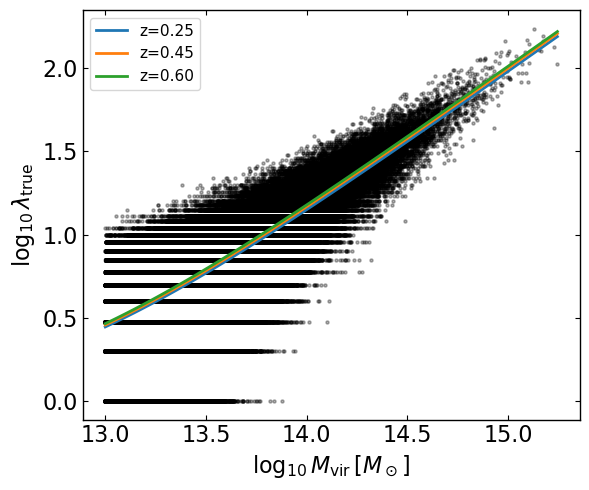

In [6]:
Mvir = np.asarray(mock['Mvir'], dtype=float)
zcl  = np.asarray(mock['redshift'], dtype=float)

lambda_true = sample_lambda_true(Mvir, zcl, rng=RNG).astype(float)
mock['lambda_true'] = lambda_true

print('mean lambda_true:', lambda_true.mean())
print('fraction lambda_true >= 5 :', (lambda_true >= 5).mean())
print('fraction lambda_true >= 20:', (lambda_true >= 20).mean())

# Sanity: expected mean relation vs sampled halos.
logM = np.log10(Mvir)
fig, ax = plt.subplots(figsize=(6, 5))
# ax.hexbin(logM, np.log10(np.clip(lambda_true, 1, None)), gridsize=60,
#           mincnt=1, cmap='Greys')
ax.scatter(logM, np.log10(np.clip(lambda_true, 1, None)), alpha=0.3, s=5, color='k')
mg = np.linspace(logM.min(), logM.max(), 80)
for zref in [0.25, 0.45, 0.60]:
    ax.plot(mg, np.log10(l_tr(10**mg, zref)), lw=2, label='z=%.2f' % zref)
ax.set_xlabel(r'$\log_{10} M_\mathrm{vir}\,[M_\odot]$')
ax.set_ylabel(r'$\log_{10} \lambda_\mathrm{true}$')
ax.legend(fontsize=11); fig.tight_layout()

Show the scatter of the sampled intrinsic richness, $\lambda_{\rm true}$, around the expected mean richness--mass relation:

$$
\log_{10}\left(
\frac{\lambda_{\rm true}}
{\langle \lambda_{\rm true} \mid M, z_{\rm ref} \rangle}
\right).
$$

The distribution is not symmetric in log space, and because the halo catalogue is dominated by low-richness halos so there is tail at lower richness.

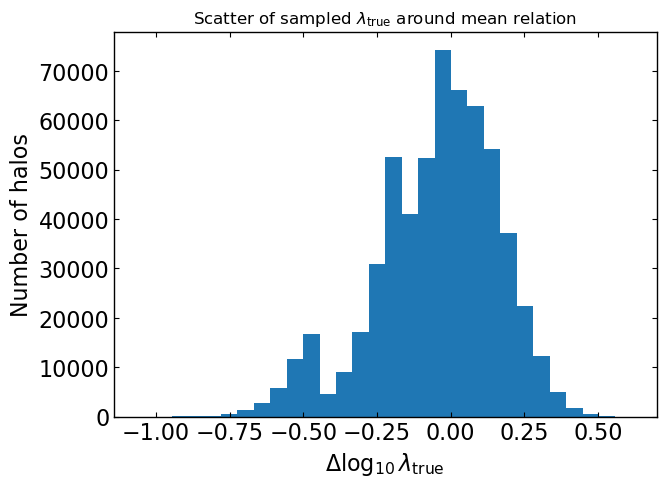

In [7]:
plt.figure(figsize=(7, 5))

# Compare each sampled lambda_true to the mean relation evaluated at that
# halo's own redshift, not at a single reference z.
plt.hist(
    np.log10(np.clip(lambda_true, 1, None)) - np.log10(l_tr(Mvir, zcl)),
    bins=30
)

plt.xlabel(r'$\Delta \log_{10} \lambda_{\rm true}$')
plt.ylabel('Number of halos')
plt.title(r'Scatter of sampled $\lambda_{\rm true}$ around mean relation')

plt.show()

## 4. Project $\lambda_\mathrm{true} \to \lambda_\mathrm{obs}$

Costanzi+2019, Eq. 6 ([arXiv:1807.07072](https://arxiv.org/abs/1807.07072)):

$$
P(\lambda_\mathrm{obs}|\lambda_\mathrm{true},z) =
(1 - f_\mathrm{prj})\,\mathcal{N}(\mu,\sigma) +
f_\mathrm{prj}\,\frac{\tau}{2}\,
\exp\!\left[\frac{\tau}{2}(2\mu + \tau\sigma^2 - 2\lambda_\mathrm{obs})\right]\,
\mathrm{erfc}\!\left(\frac{\mu + \tau\sigma^2 - \lambda_\mathrm{obs}}{\sqrt{2}\,\sigma}\right),
$$

with $\mu = \mu(\lambda_\mathrm{true}, z)$ a linear function of $\lambda_\mathrm{true}$,
$\sigma = \sigma(\lambda_\mathrm{true}, z)$ a power law, $f_\mathrm{prj}$ a sigmoid,
and $\tau$ a power law. All four parameters are evaluated from the
SDSS-calibrated posterior-mean coefficients in
`prj_params_DESY3_lss_lin_dep_getdist_v1.txt` via `projection_params`.

The mixture is sampled directly: with probability $1-f_\mathrm{prj}$ we draw
from the Gaussian; with probability $f_\mathrm{prj}$ we draw from the
exponentially-modified Gaussian as `N(mu, sigma) + Exp(1/tau)` (sum of
independent draws — the EMG closed form is the convolution of these two).

In [8]:
# --- Sample lambda_obs from Costanzi+2019 Eq. 6 ---
zcl_for_projection = np.asarray(mock['redshift_obs'], dtype=float)  # was 'redshift'
lambda_obs, f_prj, tau, mu_prj, sig_prj = sample_lambda_obs(
    lambda_true, zcl_for_projection, PRJ_INTERP, rng=RNG)

mock['lambda_obs'] = lambda_obs
mock['f_prj']      = f_prj
mock['tau_prj']    = tau
mock['mu_prj']     = mu_prj
mock['sig_prj']    = sig_prj

assert len(lambda_obs) == len(lambda_true)

dlam = lambda_obs - lambda_true
print('<lambda_true>           = %.3f' % lambda_true.mean())
print('<lambda_obs>            = %.3f' % lambda_obs.mean())
print('<Delta lambda>          = %.3f' % dlam.mean())
print('<f_prj>                 = %.3f' % f_prj.mean())
print('<1/tau>                 = %.3f' % np.mean(1.0 / tau))
print('<sigma>                 = %.3f' % sig_prj.mean())
print('<mu - lambda_true>      = %.3f' % (mu_prj - lambda_true).mean())

<lambda_true>           = 5.498
<lambda_obs>            = 5.497
<Delta lambda>          = -0.000
<f_prj>                 = 0.608
<1/tau>                 = 1.622
<sigma>                 = 2.375
<mu - lambda_true>      = -1.100


In [9]:
# === Lensing inputs (shared by analytical and empirical routes) ===
# Centralised so all the diagnostic plots downstream see the same arrays.

# --- Per-halo richness / redshift quantities ---
ltr_arr = np.asarray(mock['lambda_true'], dtype=float)
lob_arr = np.asarray(mock['lambda_obs'],  dtype=float)
zob_arr = np.asarray(mock['redshift_obs'], dtype=float)

# --- Truth quantities for (logM, z)-matched random reference ---
logM_true = np.log10(np.asarray(mock['Mvir'], dtype=float))
z_true    = np.asarray(mock['redshift_true'], dtype=float)

# --- Catalog redMaPPer outputs (used by the EMPIRICAL route) ---
lam_RM = np.asarray(mock['LAMBDA_CHISQ'], dtype=float)
z_RM   = np.asarray(mock['Z_LAMBDA'],     dtype=float)

# --- Per-halo profiles (raw, on rp_phys_mpc 15-pt grid) ---
Sigma_full  = np.asarray(mock['Sigma'])
DSigma_full = np.asarray(mock['DeltaSigma'])
R_full      = rbp.rp_phys_mpc

# --- Switch to the DES Y1 boost-factor profile R grid (physical Mpc) ---
# All 21 boost files share the same 11-point R axis from 0.166 to 15.80 Mpc.
# We log-log-interpolate every halo's Sigma(R) and DSigma(R) onto this grid
# so downstream stacks line up with the Y1 boost-factor data.
_bf_ref = ('data/boost_factor/profiles/'
          'full-unblind-v2-mcal-zmix_y1clust_l3_z0_zpdf_boost.dat')
R_BF    = np.loadtxt(_bf_ref)[:, 0]      # 11 pts, 0.166..15.80 Mpc

def _loglog_interp(R_new, R_old, Y_old):
    """Per-halo log-log linear interp; vectorised across halos.
    Y_old is (N_halo, N_R_old). Falls back to linear if any value <= 0."""
    Y_pos = Y_old > 0
    out = np.empty((Y_old.shape[0], len(R_new)))
    lnR_old = np.log(R_old)
    lnR_new = np.log(R_new)
    for i in range(Y_old.shape[0]):
        if Y_pos[i].all():
            out[i] = np.exp(np.interp(lnR_new, lnR_old, np.log(Y_old[i])))
        else:
            out[i] = np.interp(lnR_new, lnR_old, Y_old[i])
    return out

Sigma_all = _loglog_interp(R_BF, R_full, Sigma_full)
DSigma    = _loglog_interp(R_BF, R_full, DSigma_full)
del Sigma_full, DSigma_full

# --- Lensing geometry: Sigma_crit^{-1}(z_lens) ---
bTable               = np.load(floc.mock_boost_factor_1d)
betaEff              = bTable['betaEff']
zlens                = bTable['zlens']
const                = 6.01e-19 * 1e6                              # pc/Msun (4 pi G / c^2)
dlens                = cosmo0.comoving_distance(zlens).value * 1e6  # pc
sigma_crit_inv_vec   = const * dlens[:, np.newaxis] * betaEff
sigma_crit_inv_vec_z = sigma_crit_inv_vec[:, -1]

# --- Radial bin centres: DES Y1 boost-factor .dat grid (physical Mpc) ---
radii = R_BF       # 11 pts, 0.166..15.80 Mpc
assert radii.shape == (11,) and abs(radii[0] - 0.166) < 0.001

# --- Helper: bin-and-mean a per-halo profile (used by both routes) ---
def stack_in_bins(lam, z, profile, lam_bins, z_min_list, z_max_list):
    """Plain mean profile per (lam, z) bin, plus per-bin selection masks."""
    nl = len(lam_bins) - 1
    nz = len(z_min_list)
    nr = profile.shape[1]
    stacked = np.zeros((nl, nz, nr))
    counts  = np.zeros((nl, nz), dtype=int)
    masks   = [[None] * nz for _ in range(nl)]
    for il in range(nl):
        in_lam = (lam >= lam_bins[il]) & (lam < lam_bins[il + 1])
        for iz in range(nz):
            in_z = (z >= z_min_list[iz]) & (z < z_max_list[iz])
            m = in_lam & in_z
            masks[il][iz]  = m
            counts[il, iz] = int(m.sum())
            if m.any():
                stacked[il, iz] = profile[m].mean(axis=0)
    return stacked, counts, masks

### Sanity: do MC draws of $\lambda^\mathrm{ob}$ recover the analytical kernel?

Histogram repeated `sample_lambda_obs` draws at fixed $(\lambda^\mathrm{tr}, z)$ and overlay the closed-form Eq. 6 PDF. The two should match within Poisson noise.

/tmp/ipykernel_2281977/1636713312.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


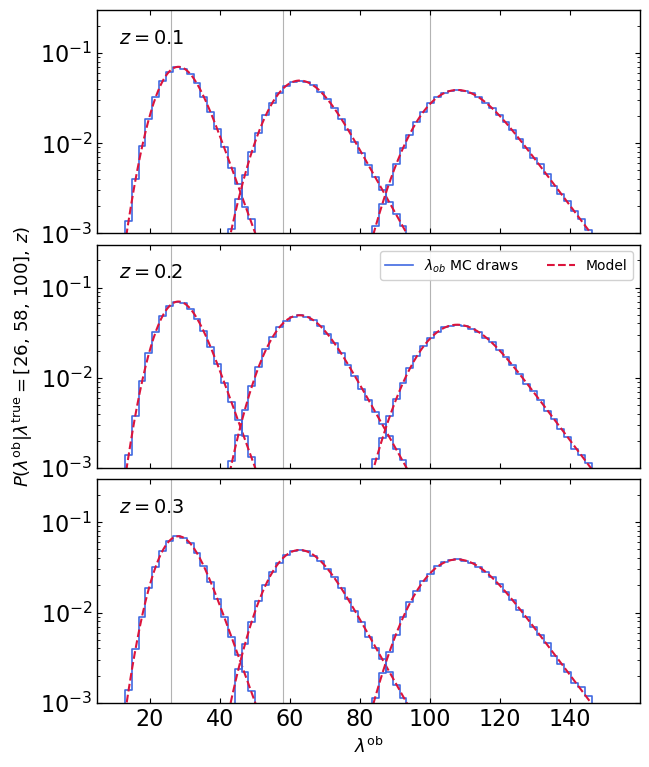

In [10]:
# --- Analytical PDF of Costanzi+2019 Eq. 6 ---------------------------------
def p_lambda_obs(lobs, ltr, z, interp):
    """
    Closed-form P(lambda_obs | lambda_true, z) from Costanzi+2019 Eq. 6.
    Evaluated point-wise: lobs (nr,), ltr scalar, z scalar.
    """
    f_prj, tau, mu, sigma = projection_params(np.asarray(ltr, float),
                                              np.asarray(z, float),
                                              interp)
    f_prj = float(f_prj); tau = float(tau); mu = float(mu); sigma = float(sigma)

    # Gaussian branch
    gauss = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(
        -0.5 * ((lobs - mu) / sigma) ** 2)

    # EMG branch — closed form. Compute the log first to avoid overflow in exp.
    a   = mu + tau * sigma ** 2 - lobs
    log_pref = np.log(tau / 2.0) + (tau / 2.0) * (2.0 * mu + tau * sigma ** 2 - 2.0 * lobs)
    emg = np.exp(log_pref) * erfc(a / (np.sqrt(2.0) * sigma))

    return (1.0 - f_prj) * gauss + f_prj * emg

# --- Settings ---
LTR_FIX = [26, 58, 100]
Z_FIX   = [0.1, 0.2, 0.3]
N_DRAWS = 200_000
BINS    = np.linspace(5, 160, 80)
BCEN    = 0.5 * (BINS[:-1] + BINS[1:])

# --- Plot ---
fig, axes = plt.subplots(len(Z_FIX), 1, figsize=(7, 9),
                          sharex=True, sharey=True,
                          gridspec_kw={'hspace': 0.05})

rng_plot = np.random.default_rng(seed=123)

for irow, z0 in enumerate(Z_FIX):
    ax = axes[irow]
    for ltr0 in LTR_FIX:
        ltr_mc  = np.full(N_DRAWS, ltr0, dtype=float)
        z_mc    = np.full(N_DRAWS, z0,   dtype=float)

        lobs_draw, *_ = sample_lambda_obs(ltr_mc,  z_mc,  PRJ_INTERP, rng=rng_plot)

        hist, _ = np.histogram(lobs_draw, bins=BINS, density=True)
        ax.step(BCEN, hist, where='mid', color='royalblue', lw=1.2,
                label=(r'$\lambda_{ob}$ MC draws'
                       if (irow == 1 and ltr0 == LTR_FIX[0]) else None))

        x = np.linspace(BINS[0], BINS[-1], 600)
        pdf = p_lambda_obs(x, ltr0, z0, PRJ_INTERP)
        ax.plot(x, pdf, '--', color='crimson', lw=1.5,
                label=('Model' if (irow == 1 and ltr0 == LTR_FIX[0]) else None))

        ax.axvline(ltr0, color='0.7', lw=0.8, zorder=0)

    ax.set_yscale('log')
    ax.set_ylim(1e-3, 3e-1)
    ax.set_xlim(5, 160)
    ax.text(0.04, 0.85, r'$z = %.1f$' % z0,
            transform=ax.transAxes, fontsize=14)

    if irow == 1:
        ax.legend(loc='upper right', fontsize=10, ncol=2,
                  frameon=True, framealpha=0.9)

# One y-label on the middle row
axes[1].set_ylabel(
    r'$P(\lambda^{\rm ob}|\lambda^{\rm true} = [26,\,58,\,100],\,z)$',
    fontsize=13,
)
axes[-1].set_xlabel(r'$\lambda^{\rm ob}$', fontsize=13)

# Linear x-axis ticks
for ax in axes:
    ax.xaxis.set_major_locator(FixedLocator([20, 40, 60, 80, 100, 120, 140]))
    ax.tick_params(axis='both', which='both', direction='in',
                   top=True, right=True)

fig.tight_layout()
plt.show()

### Decompose the kernel into Gaussian core + EMG projection tail

Same Eq. 6, split into the two physical components — at large $\lambda^\mathrm{tr}$ the EMG tail dominates the high-$\lambda^\mathrm{ob}$ side and drives the projection bias.

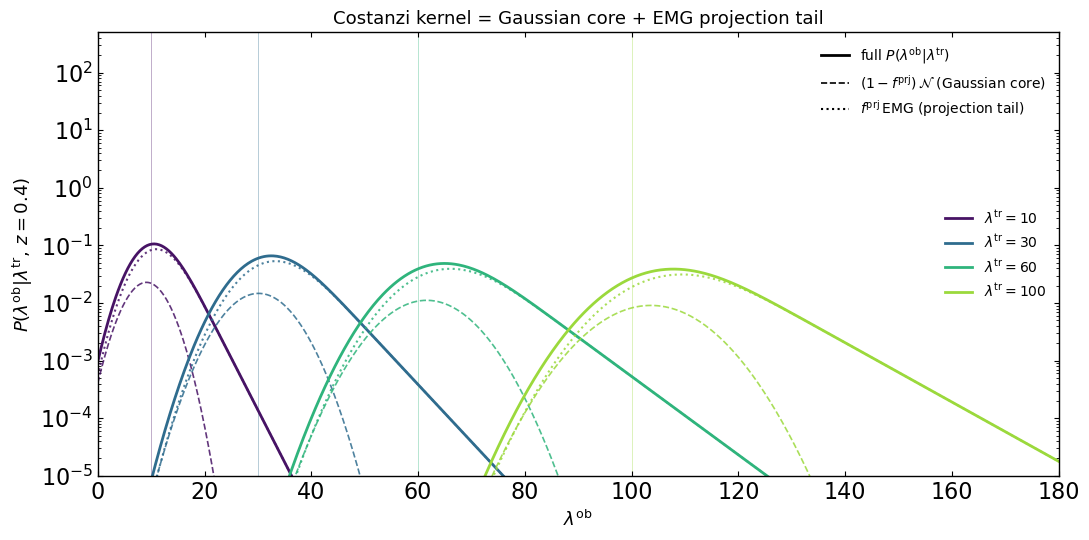

In [11]:
# --- Decomposed PDF: returns (gauss_core, emg_tail, total) at given lobs grid ---
def p_lambda_obs_decomposed(lobs, ltr, z, interp):
    """
    Returns the two components of Costanzi+2019 Eq. 6 separately:

        gauss_core  = (1 - f_prj) * N(mu, sigma)
        emg_tail    = f_prj * EMG(mu, sigma, tau)
        total       = gauss_core + emg_tail

    Each output has the same shape as `lobs`.
    """
    f_prj, tau, mu, sigma = projection_params(np.asarray(ltr, float),
                                              np.asarray(z, float),
                                              interp)
    f_prj = float(f_prj); tau = float(tau); mu = float(mu); sigma = float(sigma)

    # Gaussian component
    gauss = (1.0 / (np.sqrt(2.0 * np.pi) * sigma)) * np.exp(
        -0.5 * ((lobs - mu) / sigma) ** 2)

    # EMG component — compute log first to avoid overflow in the exponential.
    a = mu + tau * sigma ** 2 - lobs
    log_pref = np.log(tau / 2.0) + (tau / 2.0) * (2.0 * mu + tau * sigma ** 2 - 2.0 * lobs)
    emg = np.exp(log_pref) * erfc(a / (np.sqrt(2.0) * sigma))

    gauss_core = (1.0 - f_prj) * gauss
    emg_tail   = f_prj * emg
    total      = gauss_core + emg_tail
    return gauss_core, emg_tail, total


# --- Plot ---
LTR_LIST = [10, 30, 60, 100]
Z_FIX    = 0.4

# Viridis-like color sequence matching the reference plot
cmap = plt.get_cmap('viridis')
colors = [cmap(0.05), cmap(0.35), cmap(0.65), cmap(0.85)]

fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.linspace(0.01, 180, 800)

for ltr0, c in zip(LTR_LIST, colors):
    gauss_core, emg_tail, total = p_lambda_obs_decomposed(x, ltr0, Z_FIX, PRJ_INTERP)

    ax.plot(x, total,      '-',  lw=2.0, color=c, label=r'$\lambda^{\rm tr}=%i$' % ltr0)
    ax.plot(x, gauss_core, '--', lw=1.2, color=c, alpha=0.85)
    ax.plot(x, emg_tail,   ':',  lw=1.5, color=c, alpha=0.85)

    ax.axvline(ltr0, color=c, lw=0.6, alpha=0.4, zorder=0)

ax.set_yscale('log')
ax.set_xlim(0, 180)
ax.set_ylim(1e-5, 5e2)
ax.set_xlabel(r'$\lambda^{\rm ob}$', fontsize=13)
ax.set_ylabel(r'$P(\lambda^{\rm ob}|\lambda^{\rm tr},\,z=%.1f)$' % Z_FIX, fontsize=13)
ax.set_title('Costanzi kernel = Gaussian core + EMG projection tail', fontsize=13)

# Two legends: one for the component linestyles (top right area),
# one for the lambda_true colors (mid right). Use proxy artists so
# the linestyle legend isn't tied to a specific color.
style_handles = [
    Line2D([], [], color='k', ls='-',  lw=2.0, label=r'full $P(\lambda^{\rm ob}|\lambda^{\rm tr})$'),
    Line2D([], [], color='k', ls='--', lw=1.2, label=r'$(1-f^{\rm prj})\,\mathcal{N}$ (Gaussian core)'),
    Line2D([], [], color='k', ls=':',  lw=1.5, label=r'$f^{\rm prj}\,$EMG (projection tail)'),
]
leg_style = ax.legend(handles=style_handles, loc='upper right',
                       fontsize=10, frameon=False)
ax.add_artist(leg_style)
ax.legend(loc='center right', fontsize=10, frameon=False, title=None)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
fig.tight_layout()
plt.show()

## 4.5 Stacked $\Sigma(R)$ in $\lambda$ bins: true vs observed

Diagnostic that motivates the §7-§8 selection-bias machinery. The stacked profile in each bin is shaped by the **mass distribution within the bin**. Comparing two stacks at the same numerical $\lambda$ — one binned on $\lambda^\mathrm{tr}$, one on the C19 $\lambda^\mathrm{ob}$ — exposes the **mass-dilution / Eddington** piece: the $\lambda^\mathrm{ob}$ bin sweeps in extra low-mass halos via the EMG projection tail and drags the mean mass down. This is what the §7 analytical and §8 empirical corrections both target.

Halos per (lambda_true bin, z bin):
[[1382 2630 3790]
 [ 528  962 1254]
 [ 138  237  272]
 [  89  123   98]]
Halos per (lambda_obs bin, z bin):
[[2036 3949 5719]
 [ 760 1529 2009]
 [ 214  371  457]
 [ 144  202  195]]


/tmp/ipykernel_2281977/199501094.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


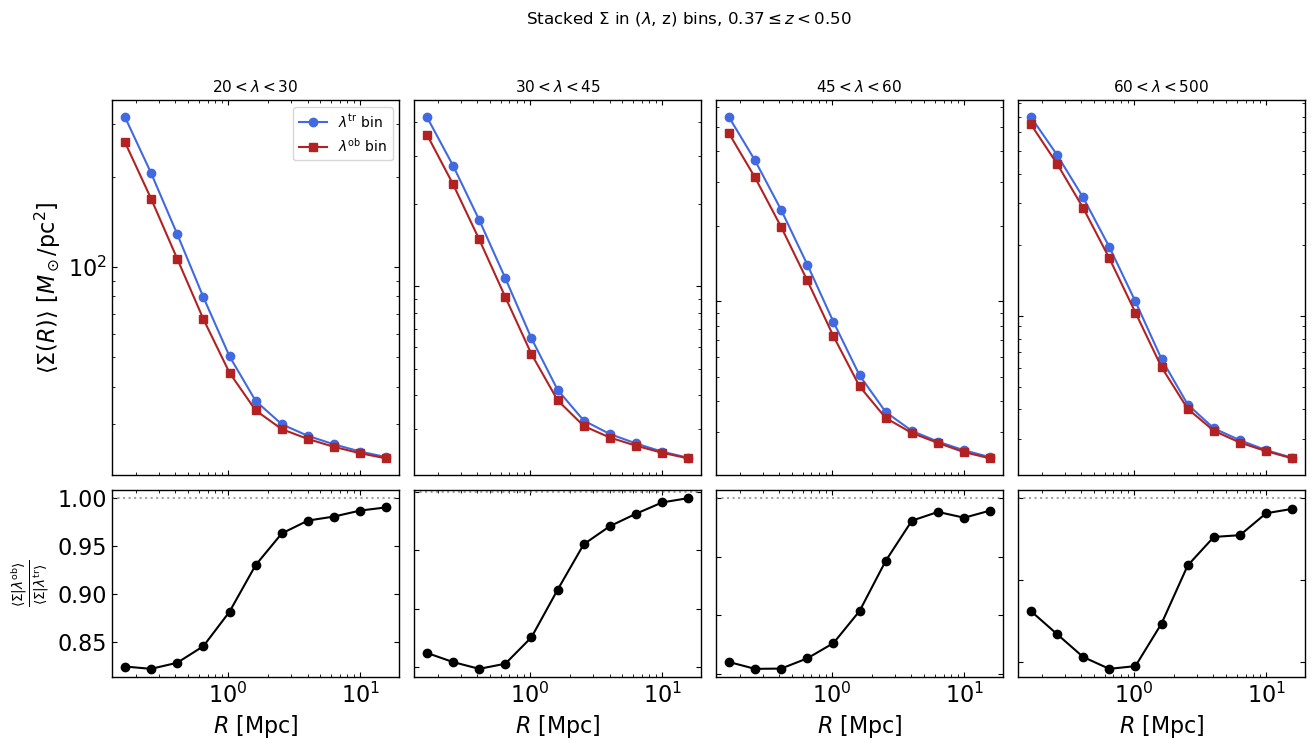

In [12]:
def stack_sigma(lam, z, Sigma, lam_bins, z_min_list, z_max_list):
    """
    Returns mean Sigma profile per (lam_bin, z_bin), shape (nl, nz, nr),
    plus halo counts per bin, shape (nl, nz).
    """
    nl = len(lam_bins) - 1
    nz = len(z_min_list)
    nr = Sigma.shape[1]
    mean_Sigma = np.zeros((nl, nz, nr))
    counts     = np.zeros((nl, nz), dtype=int)

    for il in range(nl):
        in_lam = (lam >= lam_bins[il]) & (lam < lam_bins[il + 1])
        for iz in range(nz):
            in_z = (z >= z_min_list[iz]) & (z < z_max_list[iz])
            m = in_lam & in_z
            n = int(m.sum())
            counts[il, iz] = n
            if n > 0:
                mean_Sigma[il, iz] = Sigma[m].mean(axis=0)
    return mean_Sigma, counts


Sigma_ltr, N_ltr = stack_sigma(ltr_arr, zob_arr, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST)
Sigma_lob, N_lob = stack_sigma(lob_arr, zob_arr, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST)

print("Halos per (lambda_true bin, z bin):")
print(N_ltr)
print("Halos per (lambda_obs bin, z bin):")
print(N_lob)

# --- Plot ------------------------------------------------------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)
zb = 1   # which redshift bin to show; change to taste

fig, axes = plt.subplots(2, nl, figsize=(nl * 3.6 + 1, 7.5),
                          sharex=True,
                          gridspec_kw={'hspace': 0.05, 'wspace': 0.05,
                                       'height_ratios': [3, 1.5]})

for il in range(nl):
    ax_top = axes[0, il]
    ax_bot = axes[1, il]

    s_tr = Sigma_ltr[il, zb]
    s_ob = Sigma_lob[il, zb]

    # Top: stacked Sigma profiles
    ax_top.loglog(radii, s_tr, 'o-', color='royalblue',  label=r'$\lambda^{\rm tr}$ bin')
    ax_top.loglog(radii, s_ob, 's-', color='firebrick',  label=r'$\lambda^{\rm ob}$ bin')
    ax_top.set_title(r'$%i < \lambda < %i$' % (LBDBINS[il], LBDBINS[il + 1]),
                     fontsize=11)

    # Bottom: ratio
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(s_tr > 0, s_ob / s_tr, np.nan)
    ax_bot.semilogx(radii, ratio, 'o-', color='black')
    ax_bot.axhline(1.0, ls=':', color='gray', alpha=0.7)

    ax_bot.set_xlabel(r'$R\ [{\rm Mpc}]$')

    if il > 0:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r'$\langle\Sigma(R)\rangle\ [M_\odot/{\rm pc}^2]$')
axes[1, 0].set_ylabel(
    r'$\frac{\langle\Sigma | \lambda^{\rm ob}\rangle}{\langle\Sigma | \lambda^{\rm tr}\rangle}$',
    fontsize=14,
)
axes[0, 0].legend(loc='upper right', fontsize=10)

fig.suptitle(r'Stacked $\Sigma$ in ($\lambda$, z) bins, '
             r'$%.2f \leq z < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
             y=1.00, fontsize=12)
fig.tight_layout()
plt.show()

### Costanzi+2026 Fig. 3 comparison

Cross-check the absolute amplitude and shape of $\langle\Sigma(R | \lambda^\mathrm{ob} \!\sim\! 20, z^\mathrm{ob} \!\sim\! 0.5)\rangle$ against C26 Fig. 3, with the same axes (cMpc/h, $M_\odot/(\mathrm{Mpc}/h)^2$).

Closest bin: lambda in [20, 30),  z in [0.37, 0.5)
N halos in bin: 3949


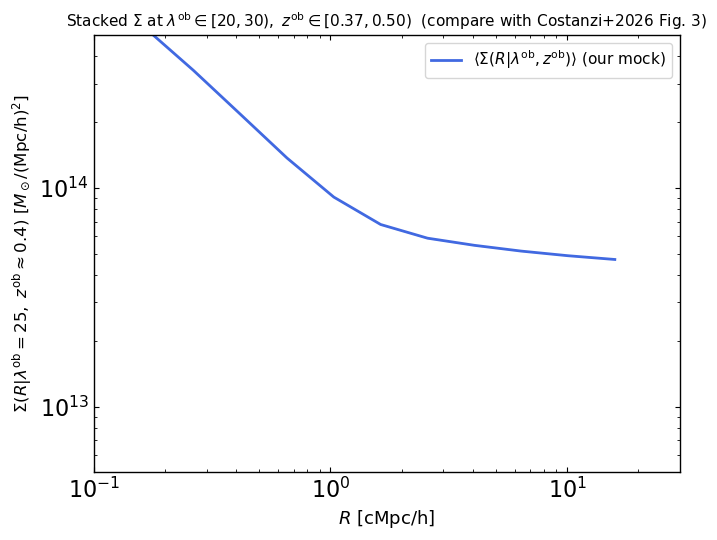

In [13]:
# --- Fig. 3 of Costanzi+2026 comparison ------------------------------------
# Their Fig. 3 shows <Sigma(R | lambda_ob=20, z_ob=0.5)> with shaded uncertainty
# from a Buzzard-like mock, decomposed into 1-halo and 2-halo terms.
#
# We can plot only the TOTAL Sigma from our mock (we don't have the 1h/2h split),
# but with the same axes and the closest matching (lambda, z) bin from our binning.

# Find the bin closest to (lambda_ob = 20, z = 0.5)
def find_bin(value, edges):
    for i in range(len(edges) - 1):
        if edges[i] <= value < edges[i + 1]:
            return i
    return len(edges) - 2

il_target = find_bin(20.0, LBDBINS)          # lambda bin containing 20
# For z, find the bin closest to 0.5 (assuming ZMIN_LIST is sorted)
iz_target = int(np.argmin(np.abs((np.array(ZMIN_LIST) + np.array(ZMAX_LIST)) / 2 - 0.5)))

print(f"Closest bin: lambda in [{LBDBINS[il_target]}, {LBDBINS[il_target+1]}),  "
      f"z in [{ZMIN_LIST[iz_target]}, {ZMAX_LIST[iz_target]})")
print(f"N halos in bin: {N_lob[il_target, iz_target]}")


# Re-stack Sigma in that one bin with per-halo errors so we can compute a band.
in_bin = ((lob_arr >= LBDBINS[il_target]) &
          (lob_arr <  LBDBINS[il_target + 1]) &
          (zob_arr >= ZMIN_LIST[iz_target])  &
          (zob_arr <  ZMAX_LIST[iz_target]))
n_bin = int(in_bin.sum())

Sigma_bin    = Sigma_all[in_bin]                          # (n_bin, nr)
mean_Sigma   = Sigma_bin.mean(axis=0)
std_Sigma    = Sigma_bin.std(axis=0)
sem_Sigma    = std_Sigma / np.sqrt(n_bin)                  # standard error of the mean

# Convert radii to comoving Mpc/h to match Costanzi+2026 Fig. 3 axis convention.
# In their plot, x = R [cMpc/h].
h     = cosmo0.h
z_rep = float(np.mean(zob_arr[in_bin]))
R_cMpc_h = radii * (1.0 + z_rep) * h

# Convert Sigma to the same units Costanzi uses on y. Their axis runs ~1e13 to 5e14
# (likely Msun / (Mpc/h)^2 or similar). Your mock Sigma is presumably Msun/pc^2.
# 1 Msun/pc^2 = 1e12 Msun/Mpc^2. So multiply by (Mpc/h)^2 / pc^2 = 1e12 / h^2.
SIGMA_UNIT_CONV = 1e12 / h ** 2            # Msun/pc^2 -> Msun/(Mpc/h)^2
mean_y = mean_Sigma * SIGMA_UNIT_CONV
sem_y  = sem_Sigma  * SIGMA_UNIT_CONV


# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.loglog(R_cMpc_h, mean_y, '-', color='royalblue', lw=2.0,
          label=r'$\langle\Sigma(R | \lambda^{\rm ob}, z^{\rm ob})\rangle$ (our mock)')
ax.fill_between(R_cMpc_h, np.maximum(mean_y - sem_y, 1e10), mean_y + sem_y,
                color='royalblue', alpha=0.25, lw=0)

ax.set_xlim(0.1, 30)
ax.set_ylim(5e12, 5e14)
ax.set_xlabel(r'$R\ [{\rm cMpc/h}]$', fontsize=13)
ax.set_ylabel(
    r'$\Sigma(R | \lambda^{\rm ob} = %d,\ z^{\rm ob} \approx %.1f)\ [M_\odot/({\rm Mpc/h})^2]$'
    % (int(0.5 * (LBDBINS[il_target] + LBDBINS[il_target + 1])), z_rep),
    fontsize=12,
)
ax.set_title(
    r'Stacked $\Sigma$ at $\lambda^{\rm ob}\in[%d,%d),\ z^{\rm ob}\in[%.2f,%.2f)$  '
    r'(compare with Costanzi+2026 Fig. 3)' %
    (LBDBINS[il_target], LBDBINS[il_target + 1],
     ZMIN_LIST[iz_target], ZMAX_LIST[iz_target]),
    fontsize=11,
)
ax.legend(fontsize=11)
ax.tick_params(direction='in', top=True, right=True, which='both')

fig.tight_layout()
plt.show()

## 5. Output 1 — $N(\lambda_\mathrm{obs}, z)$

In [14]:
def compute_number_counts(x, z, xbins, zmin_list, zmax_list):
    counts = []
    for xl, xh in zip(xbins[:-1], xbins[1:]):
        xmask = (x >= xl) & (x < xh)
        row = []
        for zl, zh in zip(zmin_list, zmax_list):
            row.append(int(np.count_nonzero(xmask & (z >= zl) & (z < zh))))
        counts.append(row)
    return np.array(counts)

# Bin on the observed (photo-z) redshift to be consistent with the
# observed-frame projection used to draw lambda_obs.
nc_obs = compute_number_counts(np.asarray(mock['lambda_obs']),
                                np.asarray(mock['redshift_obs']),
                                LBDBINS, ZMIN_LIST, ZMAX_LIST)
print('N(lambda_obs, z_obs):')
print(nc_obs)

N(lambda_obs, z_obs):
[[2036 3949 5719]
 [ 760 1529 2009]
 [ 214  371  457]
 [ 144  202  195]]


In [15]:
def omega_z_des_y1(z):
    """DES effective survey area Omega(z) in rad^2 as a function of true redshift.

    Piecewise polynomial fit from y3_cluster::OMEGA_Z_DES (Costanzi/Matteo).
    Peak value ~0.45 rad^2 ~ 1480 deg^2 = DES Y1 SPT footprint.
    """
    z_in = np.asarray(z, dtype=float)
    z = np.atleast_1d(z_in)
    omega = np.empty_like(z)

    # Highest-to-lowest order coefficients (matches np.polyval and C++ Horner).
    coef1 = [0.0,            0.0,            0.0,
             -0.00262353,    0.01940118,     0.45133063]
    coef2 = [1.33647377e+4,  1.35291046e+3,  -1.26204891e+2,
             -2.83454918e+1, -2.26465905,    3.84958753e-1]
    coef3 = [0.0,            0.0,            -1.88101967,
             4.8071839,      -4.11424324,    1.18196785]

    m1 = z < 0.504
    m2 = (z >= 0.504) & (z < 0.7)
    m3 = z >= 0.7

    omega[m1] = np.polyval(coef1, z[m1])
    omega[m2] = np.polyval(coef2, z[m2] - 0.6)   # note: shifted argument
    omega[m3] = np.polyval(coef3, z[m3])
    return omega if z_in.ndim else omega.item()   # scalar in -> scalar out

In [16]:
# === DES Y1 number-count expectation: rescale Buzzard counts by Omega(z) ====
  # N_Y1(lambda, z) ≈ N_buzz(lambda, z) × <Omega_Y1>_z-bin / Omega_buzzard
  # (assumes the underlying mass-richness HOD is the same in Y1 and Buzzard,
  #  so only the survey volume differs)

from scipy.integrate import quad

BUZZARD_AREA_DEG2 = 5025.6                      # your NSIDE=256 measurement
RAD2_TO_DEG2 = (180.0 / np.pi) ** 2
BUZZARD_AREA_RAD2 = BUZZARD_AREA_DEG2 / RAD2_TO_DEG2

def vol_weighted_omega(z_lo, z_hi, cosmo):
    """<Omega_Y1>_z-bin, weighted by dV/dOmega/dz so high-volume z dominates."""
    def num(z):
        return float(omega_z_des_y1(z)) * \
                cosmo.differential_comoving_volume(z).to('Mpc^3/sr').value
    def den(z):
        return cosmo.differential_comoving_volume(z).to('Mpc^3/sr').value
    n, _ = quad(num, z_lo, z_hi)
    d, _ = quad(den, z_lo, z_hi)
    return n / d                                # rad^2

scales = np.array([
    vol_weighted_omega(zl, zh, cosmo0) / BUZZARD_AREA_RAD2
    for zl, zh in zip(ZMIN_LIST, ZMAX_LIST)
])

print(f"Per-z-bin Y1/Buzzard area scale:")
for zl, zh, s in zip(ZMIN_LIST, ZMAX_LIST, scales):
    omega_avg = s * BUZZARD_AREA_RAD2
    print(f"  z in [{zl:.2f}, {zh:.2f}):  "
        f"<Omega_Y1>={omega_avg:.3f} rad^2  ({omega_avg*RAD2_TO_DEG2:6.0f} deg^2)  "
        f"scale={s:.4f}")

NC_Y1 = nc_obs * scales[np.newaxis, :]          # broadcast scale across richness

print(f"\nN(Buzzard sample, your area):\n{nc_obs}")
print(f"\nN(predicted DES Y1 expectation):\n{np.round(NC_Y1).astype(int)}")

Per-z-bin Y1/Buzzard area scale:
  z in [0.20, 0.33):  <Omega_Y1>=0.456 rad^2  (  1498 deg^2)  scale=0.2982
  z in [0.37, 0.50):  <Omega_Y1>=0.459 rad^2  (  1508 deg^2)  scale=0.3001
  z in [0.50, 0.65):  <Omega_Y1>=0.388 rad^2  (  1272 deg^2)  scale=0.2532

N(Buzzard sample, your area):
[[2036 3949 5719]
 [ 760 1529 2009]
 [ 214  371  457]
 [ 144  202  195]]

N(predicted DES Y1 expectation):
[[ 607 1185 1448]
 [ 227  459  509]
 [  64  111  116]
 [  43   61   49]]


In [17]:
# === DES Y1 expectation from Buzzard via per-halo area weighting (exact) =====
z_halo   = np.asarray(mock['redshift'])
lam_halo = np.asarray(mock['lambda_obs'])

# guard: OMEGA_Z_DES is only valid/positive over the DES Y1 range; the z>=0.7
# branch (SDSS_fit3) goes unphysical. Your cut is 0.65 so this is just safety.
assert z_halo.max() < 0.7, "halo z beyond OMEGA_Z_DES validity (z>=0.7)"

w_area = omega_z_des_y1(z_halo) / BUZZARD_AREA_RAD2     # Omega_Y1(z_i)/Omega_buzz

def number_counts_weighted(x, z, xbins, zmin_list, zmax_list, w):
    out = np.zeros((len(xbins) - 1, len(zmin_list)))
    for i, (xl, xh) in enumerate(zip(xbins[:-1], xbins[1:])):
        xm = (x >= xl) & (x < xh)
        for j, (zl, zh) in enumerate(zip(zmin_list, zmax_list)):
            out[i, j] = w[xm & (z >= zl) & (z < zh)].sum()
    return out

NC_Y1 = number_counts_weighted(lam_halo, z_halo, LBDBINS, ZMIN_LIST, ZMAX_LIST, w_area)

print("N(Buzzard, full area):\n", nc_obs)
print("\nN(DES Y1 expectation):\n", np.round(NC_Y1).astype(int))

N(Buzzard, full area):
 [[2036 3949 5719]
 [ 760 1529 2009]
 [ 214  371  457]
 [ 144  202  195]]

N(DES Y1 expectation):
 [[ 642 1229 1540]
 [ 241  473  546]
 [  67  116  124]
 [  45   64   51]]


In [18]:
# === NC covariance: diagonal Poisson ======================================
# Same convention as createDataVector.ipynb cell 65:
#   Cov(N_i, N_j) = N_i delta_ij
# Off-diagonal terms (sample variance, richness scattering) are not modelled
# here; the downstream likelihood is responsible for any further covariance
# augmentation if needed.
NC_flat = NC_Y1.flatten()                   # row-major: richness varies slowest, z fastest
NC_cov  = np.diag(NC_flat)                  # (12, 12) diagonal Poisson covariance

print(f'NC_flat: {NC_flat.astype(int)}')
print(f'sigma_NC: {np.round(np.sqrt(NC_flat), 1)}')
print(f'NC_cov shape: {NC_cov.shape}')

NC_flat: [ 642 1228 1539  241  472  546   67  116  123   45   64   51]
sigma_NC: [25.3 35.1 39.2 15.5 21.7 23.4  8.2 10.8 11.1  6.7  8.   7.2]
NC_cov shape: (12, 12)


## 5.5 Sanity: $\lambda^\mathrm{ob}$ from the C19 sampler vs `LAMBDA_CHISQ`

Two quantities both labelled $\lambda^\mathrm{ob}$ live in `mock`:

- **`mock['lambda_obs']`** — drawn from the Costanzi+2019 Eq. 6 kernel per halo. Reproduces the statistical distribution but is **uncorrelated with line-of-sight structure** at fixed $(M, z)$. *Used by the ANALYTICAL route below.*
- **`mock['LAMBDA_CHISQ']`** — from running redMaPPer on the Buzzard photometric catalog. Per-halo richness driven by actual galaxies projected into the photo-$z$ aperture, so it carries environment information. *Used by the EMPIRICAL route below.*

Three checks: (A) population distributions overlap; (B) per-halo values are scattered (different physical content); (C) both follow the Costanzi Eq. 15 mean richness-mass relation.

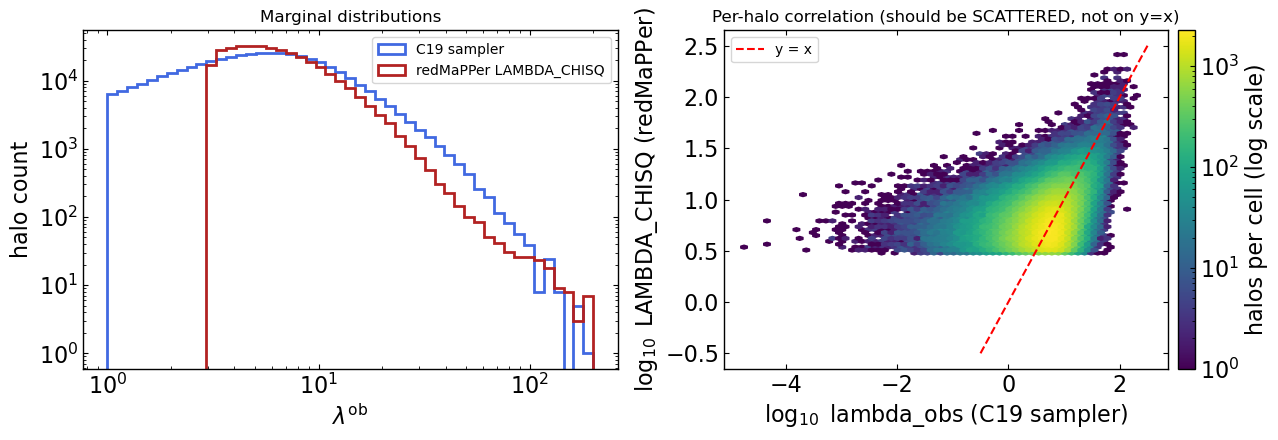

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: histograms of both definitions ---
ax = axes[0]
bins = np.logspace(0, 2.3, 50)   # log bins from lambda=1 to 200
ax.hist(lob_arr[lob_arr > 0],
        bins=bins, histtype='step', color='royalblue', lw=2,
        label='C19 sampler')
ax.hist(lam_RM[lam_RM > 0],
        bins=bins, histtype='step', color='firebrick', lw=2,
        label='redMaPPer LAMBDA_CHISQ')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\lambda^{\rm ob}$')
ax.set_ylabel('halo count')
ax.set_title('Marginal distributions')
ax.legend(loc='upper right')

# --- Right: scatter — does LAMBDA_CHISQ correlate with lambda_obs? ---
ax = axes[1]
m_valid = (lob_arr > 0) & (lam_RM > 0)
hb = ax.hexbin(np.log10(lob_arr[m_valid]),
          np.log10(lam_RM[m_valid]),
          gridsize=60, mincnt=1, cmap='viridis', bins='log')
ax.plot([-0.5, 2.5], [-0.5, 2.5], 'r--', lw=1.5, label='y = x')
ax.set_xlabel(r'$\log_{10}$ lambda_obs (C19 sampler)')
ax.set_ylabel(r'$\log_{10}$ LAMBDA_CHISQ (redMaPPer)')
ax.set_title(r'Per-halo correlation (should be SCATTERED, not on y=x)')
ax.legend()

cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label('halos per cell (log scale)')

fig.tight_layout()
plt.show()

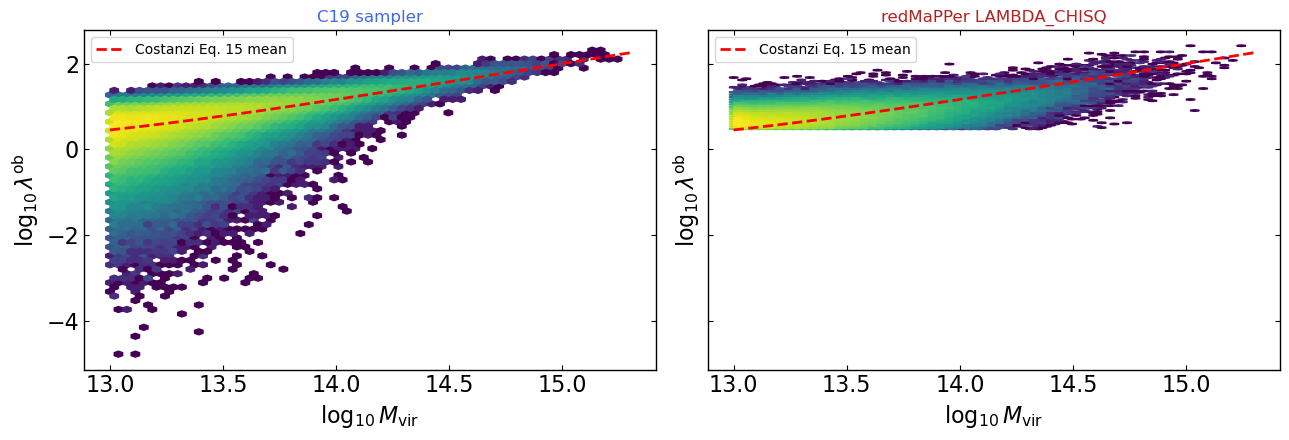

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

# Costanzi Eq. 15 mean relation at z = 0.4 (a typical sample redshift)
M_grid = np.logspace(13, 15.3, 50)
lambda_mean = 1 + l_sat(M_grid, np.full_like(M_grid, 0.4))

for ax, lam, label, color in zip(
    axes,
    [lob_arr, lam_RM],
    ['C19 sampler', 'redMaPPer LAMBDA_CHISQ'],
    ['royalblue', 'firebrick'],
):
    m_valid = lam > 0
    ax.hexbin(logM_true[m_valid], np.log10(lam[m_valid]),
              gridsize=60, mincnt=1, cmap='viridis', bins='log')
    ax.plot(np.log10(M_grid), np.log10(lambda_mean), 'r--', lw=2,
            label='Costanzi Eq. 15 mean')
    ax.set_xlabel(r'$\log_{10} M_{\rm vir}$')
    ax.set_ylabel(r'$\log_{10} \lambda^{\rm ob}$')
    ax.set_title(label, color=color)
    ax.legend(loc='upper left')

fig.tight_layout()
plt.show()

In [21]:
print(np.min(lam_RM[lam_RM>0]), np.max(lam_RM[m_valid]))
print(np.min(lob_arr[lob_arr>0]), np.max(lob_arr[m_valid]))
print(np.log10(min(lam_RM[lam_RM>0])), np.log10(min(lob_arr[lob_arr>0])))

3.0094432830810547 259.18621826171875
1.709222860063475e-05 204.2986397439336
0.4784861628869138 -4.7672013073286115


## 6. Halo mass function: Buzzard vs analytical

Sanity check on the abundance side of the data vector. Compare the binned $dn/d\log M$ from the Buzzard catalog against an analytical halo mass function from the `hmf` package, using the Bryan & Norman 1998 virial-overdensity convention that matches Buzzard's `Mvir`.

Effective sample volume: 1.729e+09  (Mpc/h)^3


/tmp/ipykernel_2281977/2594376966.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


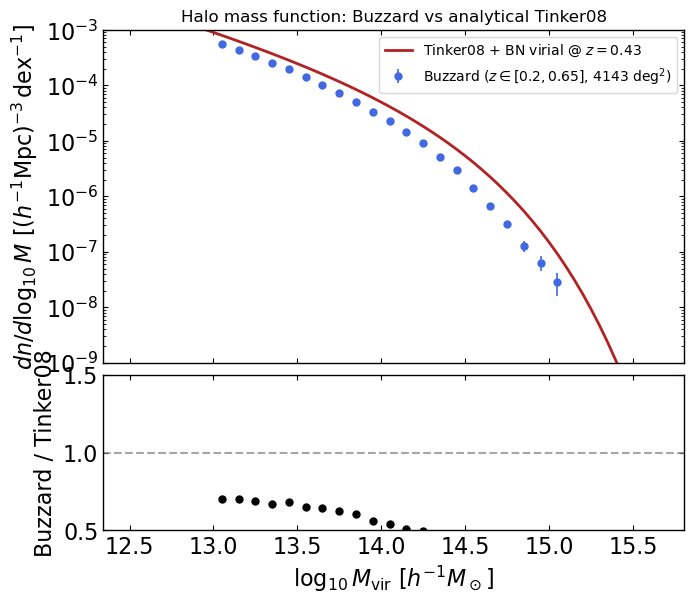

Buzzard counts per dex (first/last bin):
  log10 M = 13.05:  N =  96440,  dn/dlogM = 5.577e-04
  log10 M = 14.25:  N =   1578,  dn/dlogM = 9.125e-06
  log10 M = 15.45:  N =      0,  dn/dlogM = 0.000e+00


In [22]:
# === Section 6.6 — Buzzard HMF vs analytical (Steven Murray's `hmf`) ====
#
# The Y3 Buzzard realisation covers ~4143 deg^2 (Wu+2022 §3.1).
# Our redshift selection [0.20, 0.65] excludes [0.33, 0.37] (box seam).

import hmf
from hmf import MassFunction
from hmf.density_field.transfer_models import EH        # Eisenstein-Hu transfer
from hmf.mass_function.fitting_functions import Tinker08
from hmf.halos.mass_definitions import SOVirial          # Bryan-Norman virial

# ---------------------------------------------------------------------------
# 1. Volume probed by the sample
# ---------------------------------------------------------------------------
SKY_AREA_DEG2 = 4143.0                            # DES Y3 Buzzard area
SKY_FRAC      = SKY_AREA_DEG2 / 41252.96          # fraction of full sky
SEAM_LO, SEAM_HI = 0.33, 0.37

def comoving_volume_shell(zlo, zhi, cosmo):
    """Full-sky comoving volume between zlo and zhi, in (Mpc/h)^3."""
    Vlo = cosmo.comoving_volume(zlo).to('Mpc3').value
    Vhi = cosmo.comoving_volume(zhi).to('Mpc3').value
    return (Vhi - Vlo) * cosmo.h ** 3              # Mpc^3 -> (Mpc/h)^3

# Volume = sky-fraction × (full shell minus seam shell)
V_full = comoving_volume_shell(ZMIN, ZMAX, cosmo0)
V_seam = comoving_volume_shell(SEAM_LO, SEAM_HI, cosmo0)
V_sample_hinvMpc3 = SKY_FRAC * (V_full - V_seam)
print(f"Effective sample volume: {V_sample_hinvMpc3:.3e}  (Mpc/h)^3")


# ---------------------------------------------------------------------------
# 2. Buzzard binned dn/dlogM (per (Mpc/h)^3 per dex)
# ---------------------------------------------------------------------------
# Convert to h^-1 Msun units to match hmf convention
h = cosmo0.h
logM_h = np.log10(np.asarray(mock['Mvir']) * h)    # log10(M h / Msun)

# Bin centers spaced 0.1 dex
dlogM = 0.1
mass_bin_edges = np.arange(13.0, 15.6, dlogM)
mass_bin_centers = 0.5 * (mass_bin_edges[:-1] + mass_bin_edges[1:])

N_bin, _   = np.histogram(logM_h, bins=mass_bin_edges)
dn_dlogM_buzzard = N_bin / V_sample_hinvMpc3 / dlogM         # (Mpc/h)^-3 dex^-1
err_buzzard      = np.sqrt(N_bin) / V_sample_hinvMpc3 / dlogM


# ---------------------------------------------------------------------------
# 3. Analytical HMF (Tinker08, Bryan-Norman virial, same cosmology)
# ---------------------------------------------------------------------------
z_eval = 0.5 * (ZMIN + ZMAX)        # representative redshift for the comparison

mf = MassFunction(
    z=z_eval,
    Mmin=12.5, Mmax=15.7, dlog10m=0.05,
    cosmo_model=cosmo0,             # FlatLambdaCDM from cell 3
    sigma_8=0.82,                   # Buzzard cosmology (Wu+2022 §1)
    n=0.96,                         # spectral index
    transfer_model=EH,              # E&H transfer function
    hmf_model=Tinker08,
    mdef_model=SOVirial,            # Bryan-Norman virial — matches Buzzard Mvir
)
logM_hmf = np.log10(mf.m)            # already in h^-1 Msun
dn_dlogM_hmf = mf.dndlog10m          # (Mpc/h)^-3 dex^-1


# ---------------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------------
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7.5, 6.5), sharex=True,
    gridspec_kw={'hspace': 0.05, 'height_ratios': [3, 1.4]},
)

ax_top.errorbar(mass_bin_centers, dn_dlogM_buzzard, yerr=err_buzzard,
                fmt='o', color='royalblue', ms=5, lw=1.2,
                label=f'Buzzard ($z \\in [{ZMIN},{ZMAX}]$, '
                      f'{SKY_AREA_DEG2:.0f} deg$^2$)')
ax_top.plot(logM_hmf, dn_dlogM_hmf, '-', color='firebrick', lw=2.0,
            label=f'Tinker08 + BN virial @ $z = {z_eval:.2f}$')
ax_top.set_yscale('log')
ax_top.set_ylabel(r'$dn/d\log_{10} M\ [(h^{-1}{\rm Mpc})^{-3}\,{\rm dex}^{-1}]$')
ax_top.set_ylim(1e-9, 1e-3)
ax_top.legend(loc='upper right', fontsize=10)
ax_top.set_title(r'Halo mass function: Buzzard vs analytical Tinker08')

# Bottom: ratio
hmf_interp = np.interp(mass_bin_centers, logM_hmf, dn_dlogM_hmf)
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = dn_dlogM_buzzard / hmf_interp
    ratio_err = err_buzzard / hmf_interp

ax_bot.errorbar(mass_bin_centers, ratio, yerr=ratio_err,
                fmt='o', color='black', ms=5, lw=1.2)
ax_bot.axhline(1.0, ls='--', color='gray', alpha=0.7)
ax_bot.set_ylim(0.5, 1.5)
ax_bot.set_ylabel('Buzzard / Tinker08')
ax_bot.set_xlabel(r'$\log_{10} M_{\rm vir}\ [h^{-1} M_\odot]$')

fig.tight_layout()
plt.show()


print(f"Buzzard counts per dex (first/last bin):")
for i in [0, len(N_bin) // 2, len(N_bin) - 1]:
    print(f"  log10 M = {mass_bin_centers[i]:.2f}:  "
          f"N = {N_bin[i]:6d},  dn/dlogM = {dn_dlogM_buzzard[i]:.3e}")

## 7. Lensing data vector — ANALYTICAL route (Matteo / C26 Eq. C1)

**Binning quantity:** the C19 forward-model $(\lambda^\mathrm{ob}, z^\mathrm{ob})$ — kernel-driven, no per-halo LSS information.

**Selection bias:** the C26 Appendix C fitting function (5 constants, no integration). Matteo (priv. comm.) reports the same form fits $\Delta\Sigma$:

$$
\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R) =
A\,\left(\frac{R}{R_0}\right)^{\alpha}
\left[\,1 + \left(\frac{R}{R_0}\right)^{\gamma}\,\right]^{(\beta-\alpha)/\gamma}
+ C,
$$

with $(A, \alpha, \beta, \gamma, C) = (0.12,\,4.11,\,-0.18,\,1.82,\,1.00)$, $R_0 = R_\lambda(1+z)$, $R_\lambda = (\lambda^\mathrm{ob}/100)^{0.2}\,h^{-1}\mathrm{Mpc}$ (C26 Appendix B). Data vector:

$$
\Delta\Sigma_\mathrm{obs}(R) = \mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R)\,\Delta\Sigma_\mathrm{stack}(R),\qquad
\langle\gamma_t(R)\rangle = \Delta\Sigma_\mathrm{obs}(R)\,\Sigma_\mathrm{crit}^{-1}(\langle z^\mathrm{ob}\rangle).
$$

Use this for an MCMC chain that needs cheap per-sample evaluations.

In [23]:
# === Analytical route: C26 Eq. C1 selection bias on DeltaSigma_C19 ===

# Matteo's mean-fit constants (priv. comm.) for the bias on DeltaSigma:
A_DS, ALPHA_DS, BETA_DS, GAMMA_DS, C_DS = 0.12, 4.11, -0.18, 1.82, 1.00
# C26 Appendix C published constants for the bias on Sigma (overlay only):
A_S,  ALPHA_S,  BETA_S,  GAMMA_S,  C_S  = 0.10, 0.92, -0.53, 4.10, 1.00


def _Bsel_C1(R_phys_mpc, lambda_rep, z_rep, A, alpha, beta, gamma, C, h):
    """Generic C26 Eq. C1 fitting form. R input is physical Mpc."""
    R_phys_mpc = np.asarray(R_phys_mpc, dtype=float)
    R_cMpc_h   = R_phys_mpc * (1.0 + z_rep) * h
    R0         = (lambda_rep / 100.0) ** 0.2 * (1.0 + z_rep)
    x          = R_cMpc_h / R0
    return A * x ** alpha * (1.0 + x ** gamma) ** ((beta - alpha) / gamma) + C


def Bsel_C1_DSigma(R, lam, z, h=None):
    if h is None: h = cosmo0.h
    return _Bsel_C1(R, lam, z, A_DS, ALPHA_DS, BETA_DS, GAMMA_DS, C_DS, h)


def Bsel_C1_Sigma(R, lam, z, h=None):
    if h is None: h = cosmo0.h
    return _Bsel_C1(R, lam, z, A_S,  ALPHA_S,  BETA_S,  GAMMA_S,  C_S,  h)


# --- Stack DeltaSigma_true on the C19 (lambda_obs, z_obs) bins -------------
DSigma_lob_C19, N_lob_C19, lob_masks = stack_in_bins(
    lob_arr, zob_arr, DSigma, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- Per-bin analytical biases and observed shear --------------------------
Bsel_DSigma_C1   = np.zeros_like(DSigma_lob_C19)
Bsel_Sigma_C1    = np.zeros_like(DSigma_lob_C19)
DSigma_obs_C1    = np.zeros_like(DSigma_lob_C19)
shear_C19_C1     = np.zeros_like(DSigma_lob_C19)   # analytical observed shear
shear_C19_stack  = np.zeros_like(DSigma_lob_C19)   # no-correction reference

for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = lob_masks[il][iz]
        if not m.any():
            continue
        lam_rep = float(np.mean(lob_arr[m]))
        z_rep   = float(np.mean(zob_arr[m]))

        Bsel_DSigma_C1[il, iz] = Bsel_C1_DSigma(radii, lam_rep, z_rep)
        Bsel_Sigma_C1 [il, iz] = Bsel_C1_Sigma (radii, lam_rep, z_rep)
        DSigma_obs_C1 [il, iz] = DSigma_lob_C19[il, iz] * Bsel_DSigma_C1[il, iz]

        scinv_bin = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))
        shear_C19_stack[il, iz] = DSigma_lob_C19[il, iz] * scinv_bin
        shear_C19_C1   [il, iz] = DSigma_obs_C1 [il, iz] * scinv_bin


# --- Sanity printout -------------------------------------------------------
print('Halos per (lambda_obs, z_obs) C19 bin:')
print(N_lob_C19)
R_grid = np.array([0.04, 0.3, 1.0, 3.0, 10.0])
print('B_C1^DSigma at R = %s Mpc, lambda=30, z=0.3:' % R_grid.tolist())
print(np.round(Bsel_C1_DSigma(R_grid, 30.0, 0.3), 4))

Halos per (lambda_obs, z_obs) C19 bin:
[[2036 3949 5719]
 [ 760 1529 2009]
 [ 214  371  457]
 [ 144  202  195]]
B_C1^DSigma at R = [0.04, 0.3, 1.0, 3.0, 10.0] Mpc, lambda=30, z=0.3:
[1.     1.0004 1.0184 1.0698 1.0775]


### 7.1  Selection-bias ratio $\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R)$

/tmp/ipykernel_2281977/687041390.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


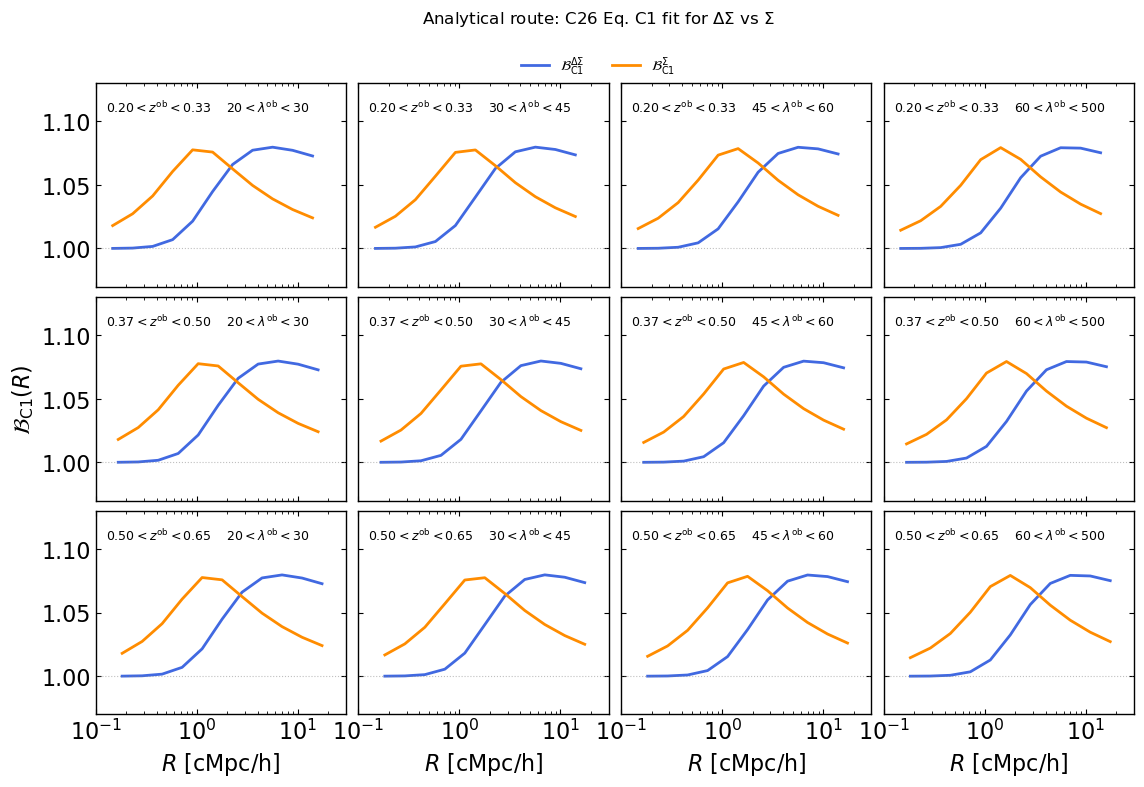

In [24]:
# --- Analytical route: B_sel(R) panel grid (ratio plot) --------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)
h  = cosmo0.h

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 3.2 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        m = lob_masks[il][iz]
        if not m.any():
            continue
        z_rep    = float(np.mean(zob_arr[m]))
        R_cMpc_h = radii * (1.0 + z_rep) * h

        ax.semilogx(R_cMpc_h, Bsel_DSigma_C1[il, iz], '-',
                    color='royalblue', lw=2.0,
                    label=r'$\mathcal{B}^{\Delta\Sigma}_{\rm C1}$'
                          if (iz == 0 and il == 0) else None)
        ax.semilogx(R_cMpc_h, Bsel_Sigma_C1[il, iz], '-',
                    color='darkorange', lw=2.0,
                    label=r'$\mathcal{B}^{\Sigma}_{\rm C1}$'
                          if (iz == 0 and il == 0) else None)
        ax.axhline(1.0, ls=':', color='gray', alpha=0.5, lw=0.8)
        ax.set_ylim(0.97, 1.13)
        ax.set_xlim(1e-1, 3e1)
        ax.text(
            0.04, 0.92,
            r'$%.2f < z^{\rm ob} < %.2f$    $%i < \lambda^{\rm ob} < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

for il in range(nl):
    axes[-1, il].set_xlabel(r'$R\ [{\rm cMpc/h}]$')
axes[nz // 2, 0].set_ylabel(r'$\mathcal{B}_{\rm C1}(R)$')
# Top-of-figure legend so it doesn't collide with per-panel bin labels.
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.tight_layout()
fig.subplots_adjust(top=0.88)   # reserve the top 12% for title + legend

fig.suptitle(
    r'Analytical route: C26 Eq. C1 fit for $\Delta\Sigma$ vs $\Sigma$',
    y=0.97, fontsize=12,
)

fig.legend(
    handles, labels,
    loc='upper center',                  # anchor the TOP of the legend
    bbox_to_anchor=(0.5, 0.93),          # ...at y=0.93, below the title
    ncol=2, fontsize=10, frameon=False,
)

plt.show()

### 7.2  Tangential shear: with vs without the C1 correction

Per richness bin in the middle redshift slice, comparing the C19 stack alone (no correction) against the same stack multiplied by $\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R)$.

/tmp/ipykernel_2281977/4221425896.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


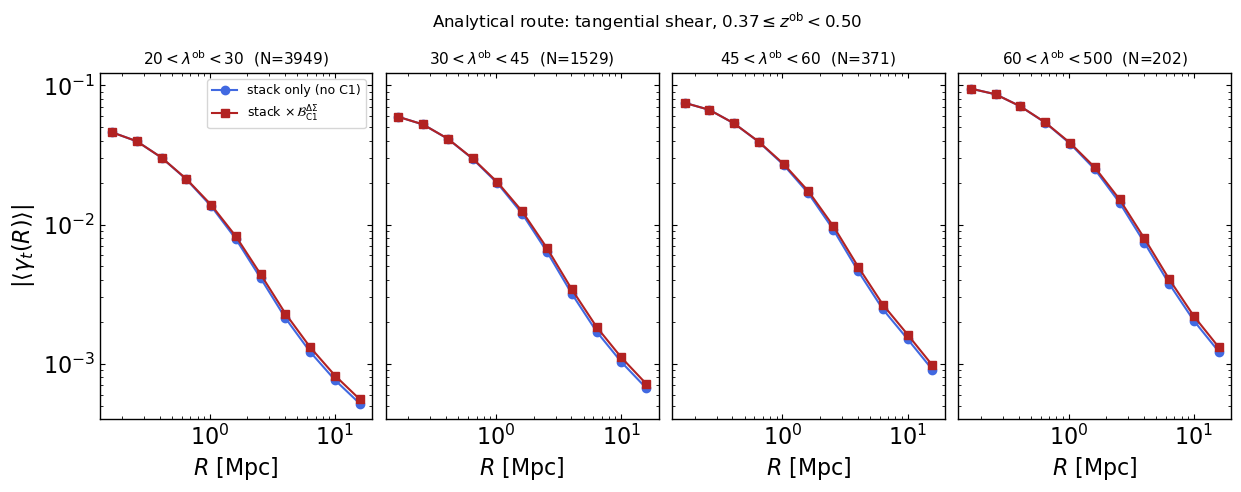

In [25]:
# --- Analytical route: tangential shear, with vs without C1 correction -----
zb = 1   # redshift bin to display

fig, axes = plt.subplots(
    1, nl, figsize=(nl * 3.4 + 1, 4.5),
    sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.05},
)

for il in range(nl):
    ax = axes[il]
    s_stack = shear_C19_stack[il, zb]     # no correction
    s_obs   = shear_C19_C1   [il, zb]     # stack x B_C1

    ax.loglog(radii, np.abs(s_stack), 'o-', color='royalblue',
              label=r'stack only (no C1)')
    ax.loglog(radii, np.abs(s_obs),   's-', color='firebrick',
              label=r'stack $\times\,\mathcal{B}^{\Delta\Sigma}_{\rm C1}$')

    ax.set_title(
        r'$%i < \lambda^{\rm ob} < %i$  (N=%d)' %
        (LBDBINS[il], LBDBINS[il + 1], N_lob_C19[il, zb]),
        fontsize=11,
    )
    ax.set_xlabel(r'$R\ [{\rm Mpc}]$')
    if il > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r'$|\langle\gamma_t(R)\rangle|$')
axes[0].legend(loc='upper right', fontsize=9)

fig.suptitle(
    r'Analytical route: tangential shear, '
    r'$%.2f \leq z^{\rm ob} < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
    y=1.02, fontsize=12,
)
fig.tight_layout()
plt.show()

### 7.3  Boost factor injection — member-galaxy contamination $B(R)$

In a real DES Y1 measurement, the source catalog includes a residual population of cluster-member galaxies that photo-$z$ failures place behind the cluster. These members carry no shear signal and **dilute** $\Delta\Sigma_{\rm meas}$; the analysis pipeline divides this out using a measured boost factor $B(R) \geq 1$ (see [McClintock+2019](https://arxiv.org/abs/1805.00039) §4.4, [Varga+2019](https://arxiv.org/abs/1812.05116)).

Our Buzzard $\Delta\Sigma$ is computed from true particles around each halo — by construction $B(R) \equiv 1$ in the simulation. To produce a mock that mimics the *raw* DES Y1 data vector, we inject the dilution analytically using the parametric form of [Sheldon+2004](https://arxiv.org/abs/astro-ph/0312036) (also used by Arwa's [boost-factor likelihood module](https://github.com/Arwa-Mq/Boost_factor_cosmosis)):

$$
B(R; r_s, b_0) = 1 + b_0\,\frac{1 - f(x)}{x^2 - 1},\qquad x = R/r_s,\qquad
f(x) = \begin{cases}\arctan(\sqrt{x^2-1})/\sqrt{x^2-1}, & x>1 \\ \mathrm{arctanh}(\sqrt{1-x^2})/\sqrt{1-x^2}, & x<1\end{cases}
$$

with the analytic limit $B(R=r_s) = (b_0 + 3)/3$. Per-bin $(\log r_s, \log b_0)$ are taken from McClintock+2019 Table II.

The contaminated data vector is then
$$\Delta\Sigma_{\rm mock\,obs}(R) = \frac{\Delta\Sigma_{\rm stack}(R)\,\mathcal{B}_{\rm sel,C1}(R)}{B(R)}.$$

In [26]:
# === 7.3  Boost factor injection ===========================================
# Parametric B(R; rs, b0) — Sheldon+2004 / Varga+2019 / McClintock+2019.
# Adapted from Arwa's CosmoSIS module:
# https://github.com/Arwa-Mq/Boost_factor_cosmosis

def boost_factor_model(R, rs, b0):
    """B(R) = 1 + b0 (1 - f(x)) / (x^2 - 1), x = R/rs. R and rs in same units."""
    x   = np.atleast_1d(np.asarray(R, dtype=float) / rs)
    B   = np.empty_like(x)
    tol = 1e-6

    m_gt = (x > 1 + tol)
    m_lt = (x < 1 - tol)
    m_eq = ~(m_gt | m_lt)

    if m_gt.any():
        s = np.sqrt(x[m_gt]**2 - 1.0)
        f = np.arctan(s) / s
        B[m_gt] = 1.0 + b0 * (1.0 - f) / (x[m_gt]**2 - 1.0)
    if m_lt.any():
        s = np.sqrt(1.0 - x[m_lt]**2)
        f = np.arctanh(s) / s
        B[m_lt] = 1.0 + b0 * (1.0 - f) / (x[m_lt]**2 - 1.0)
    if m_eq.any():
        B[m_eq] = (b0 + 3.0) / 3.0       # analytic limit at x = 1
    return B


# --- Per-bin (log rs, log b0): McClintock+2019 Table B1 --------------------
# fill in the published Y1 best-fits per (lambda, z) bin.
# Indexing: BOOST_PARAMS[(il, iz)] = (Rs [physical Mpc], B0)  — LINEAR units.
BOOST_PARAMS = {
    (0, 0): (0.44, 0.34),   (0, 1): (0.89, 0.05),   (0, 2): (0.38, 0.13),
    (1, 0): (0.50, 0.37),   (1, 1): (0.44, 0.14),   (1, 2): (0.44, 0.13),
    (2, 0): (0.80, 0.27),   (2, 1): (1.72, 0.05),   (2, 2): (0.85, 0.09),
    (3, 0): (1.37, 0.23),   (3, 1): (0.51, 0.21),   (3, 2): (35.94, 0.03),  # see note
}

# --- Build B(R) per (lambda_ob, z_ob) bin on the shared `radii` grid -------
h = cosmo0.h
B_grid = np.ones_like(DSigma_lob_C19)             # shape (nl, nz, nR)

for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = lob_masks[il][iz]
        if not m.any():
            continue
        z_rep    = float(np.mean(zob_arr[m]))
        #R_cMpc_h = radii * (1.0 + z_rep) * h      # comoving Mpc/h to match rs units
        rs, b0 = BOOST_PARAMS[(il, iz)]
        B_grid[il, iz] = boost_factor_model(radii, rs, b0)

# --- Apply: contaminated mock data vector ----------------------------------
# DSigma_obs_C1 already contains the C26 B_sel multiplicative correction.
DSigma_mock_obs = DSigma_obs_C1 / B_grid

In [27]:
shear_mock_obs  = np.zeros_like(DSigma_mock_obs)

for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = lob_masks[il][iz]
        if not m.any():
            continue
        z_rep = float(np.mean(zob_arr[m]))
        scinv_bin = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z)) 
        # ^ use your existing per-bin Sigma_crit^{-1} interpolation here
        shear_mock_obs[il, iz] = DSigma_mock_obs[il, iz] * scinv_bin

### $B(R)$ and $f_{cl}(R)$ panel grid

$$B(R) = \frac{1}{1-f_{cl}(R)} $$

/tmp/ipykernel_2281977/3597217165.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.05, 0, 1, 1])   # leave room for the shared y-label


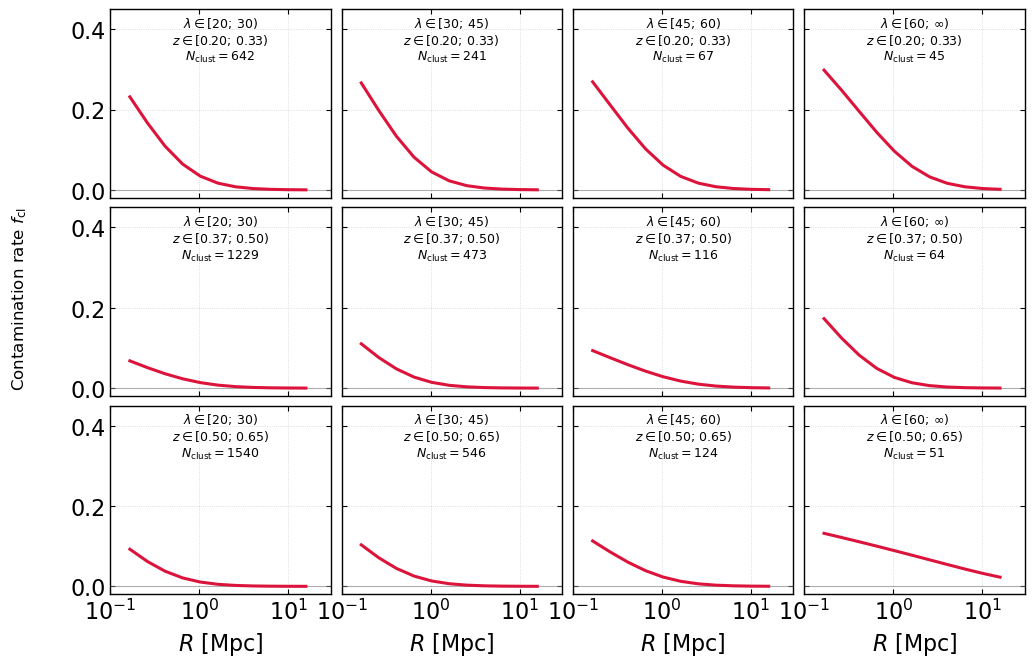

In [28]:
from matplotlib.ticker import LogLocator, NullLocator

nl, nz = len(LBDBINS) - 1, len(ZMIN_LIST)
f_cl_grid = 1.0 - 1.0 / B_grid
R_CUT = 0.2  # Mpc — McClintock+2019 / Varga+2019 analysis floor

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 2.8 + 0.6, nz * 2.4 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        m = lob_masks[il][iz]
        N_clust = int(round(NC_Y1[il, iz]))#int(m.sum())
        if not m.any():
            ax.set_xscale('log')
            continue
        z_rep    = float(np.mean(zob_arr[m]))
        #R_cMpc_h = radii * (1.0 + z_rep) * h
        f_cl     = f_cl_grid[il, iz]
        
        # split into below-floor (gray, extrapolated) and above-floor (red)
        #below = radii <=  R_CUT
        #above = radii >= R_CUT

        #ax.semilogx(R_cMpc_h[below], f_cl[below], '-',
        #            color='lightgray', lw=2.2, alpha=0.6, zorder=2)
        ax.semilogx(radii, f_cl, '-',
                    color='crimson',  lw=2.2, zorder=3)
        
        #ax.axvspan(1e-1, 0.2, color='gray', alpha=0.15, zorder=0)   # shade R<0.2 Mpc
        ax.axhline(0.0, ls='-', color='gray', alpha=0.6, lw=0.8)

        ax.grid(True, which='major', axis='x', ls=':', color='gray', alpha=0.35, lw=0.6)
        ax.grid(True, which='major', axis='y', ls=':', color='gray', alpha=0.35, lw=0.6)
        ax.xaxis.set_minor_locator(NullLocator())   # hide the 2,3,...,9 subticks too

        ax.set_ylim(-0.02, 0.45)
        ax.set_xlim(1e-1, 3e1)
        ax.set_yticks([0.0, 0.2, 0.4])

        # --- top-centre annotation: lambda range, z range, N_clust ---------
        lam_lo, lam_hi = LBDBINS[il], LBDBINS[il + 1]
        lam_hi_str = r'\infty' if not np.isfinite(lam_hi) or lam_hi >= 500 else f'{int(lam_hi)}'
        label = (
            rf'$\lambda \in [{int(lam_lo)};\,{lam_hi_str})$' + '\n'
            rf'$z \in [{ZMIN_LIST[iz]:.2f};\,{ZMAX_LIST[iz]:.2f})$' + '\n'
            rf'$N_{{\rm clust}}={N_clust}$'
        )
        ax.text(0.5, 0.97, label, transform=ax.transAxes,
                fontsize=9, va='top', ha='center')

# --- axis labels: outer only -----------------------------------------------
for il in range(nl):
    axes[-1, il].set_xlabel(r'$R\ [{\rm Mpc}]$')
fig.text(0.04, 0.5, r'Contamination rate $f_{\rm cl}$',
         va='center', rotation='vertical', fontsize=12)

fig.tight_layout(rect=[0.05, 0, 1, 1])   # leave room for the shared y-label
plt.show()

### 7.3.bis  Data-driven boost factor — DES Y1 profile measurements

Switches the boost-factor pipeline from the McClintock+2019 parametric fit (used in §7.3 above for sanity) to the **measured DES Y1 boost profiles** in `data/boost_factor/profiles/`. These are the actual
$B(R)$ values plus their covariance matrices, fit on the Y1 cluster sample with the photo-$z$ PDF reweighting.

Mapping of richness bins: the data files use 7 fine cosmology bins `l0..l6`. The 4 lensing bins here correspond to $\lambda \in [20, 30) \to$ `l3`, $[30, 45) \to$ `l4`, $[45, 60) \to$ `l5`, $[60, \infty) \to$ `l6` (lower-richness files `l0..l2` are not used).

The data-driven contaminated mock signal is
$$\Delta\Sigma_{\rm mock\,obs}(R) = \frac{\Delta\Sigma_{\rm stack}(R)\,\mathcal{B}^{\Delta\Sigma}_{\rm sel,C1}(R)}{B_{\rm Y1\,data}(R)},$$
evaluated on the same 11-point $R$ grid as the boost-factor profiles. This is the version saved to `output/MockDataVector.npz` for the downstream Matteo likelihood.

In [29]:
# === 7.3.bis  Data-driven boost factor from DES Y1 profile measurements ===
# Mapping:  (il=0, λ∈[20,30)) → l3, il=1 → l4, il=2 → l5, il=3 → l6.
LAMBDA_TO_L = {0: 3, 1: 4, 2: 5, 3: 6}

B_data       = np.zeros((nl, nz, len(radii)))             # (4, 3, 11)
B_data_err   = np.zeros_like(B_data)
B_data_cov   = np.zeros((nl, nz, len(radii), len(radii))) # (4, 3, 11, 11)

for il in range(nl):
    for iz in range(nz):
        l_data = LAMBDA_TO_L[il]
        prof = np.loadtxt(
            f'data/boost_factor/profiles/'
            f'full-unblind-v2-mcal-zmix_y1clust_l{l_data}_z{iz}_zpdf_boost.dat')
        cov  = np.loadtxt(
            f'data/boost_factor/profiles/'
            f'full-unblind-v2-mcal-zmix_y1clust_l{l_data}_z{iz}_zpdf_boost_cov.dat')
        # prof columns: R, B(R), B_err
        assert np.allclose(prof[:, 0], radii), 'R-grid mismatch with radii'
        B_data[il, iz]     = prof[:, 1]
        B_data_err[il, iz] = prof[:, 2]
        B_data_cov[il, iz] = cov

# Final mock-observed signal: optical-selection bias × data dilution.
# DSigma_obs_C1 already contains the C26 B_sel multiplicative correction.
DSigma_mock_obs_data = DSigma_obs_C1 / B_data
shear_mock_obs_data  = np.zeros_like(DSigma_mock_obs_data)

for il in range(nl):
    for iz in range(nz):
        m = lob_masks[il][iz]
        if not m.any():
            continue
        z_rep     = float(np.mean(zob_arr[m]))
        scinv_bin = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))
        shear_mock_obs_data[il, iz] = DSigma_mock_obs_data[il, iz] * scinv_bin

print(f'B_data shape:           {B_data.shape}')
print(f'B_data range:           [{B_data.min():.4f}, {B_data.max():.4f}]')
print(f'B_data_cov shape:       {B_data_cov.shape}')
print(f'shear_mock_obs_data:    {shear_mock_obs_data.shape}')

B_data shape:           (4, 3, 11)
B_data range:           [1.0000, 1.4013]
B_data_cov shape:       (4, 3, 11, 11)
shear_mock_obs_data:    (4, 3, 11)


### Diagnostic: measured $B(R)$ profiles per $(\lambda, z)$ bin

The same panel layout as the §7.3 model-based plot above, but showing the raw .dat measurements with their reported error bars. Compare with the McClintock+19 parametric model to see the agreement (and where the parametric fit smooths over data features).

/tmp/ipykernel_2281977/337205541.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


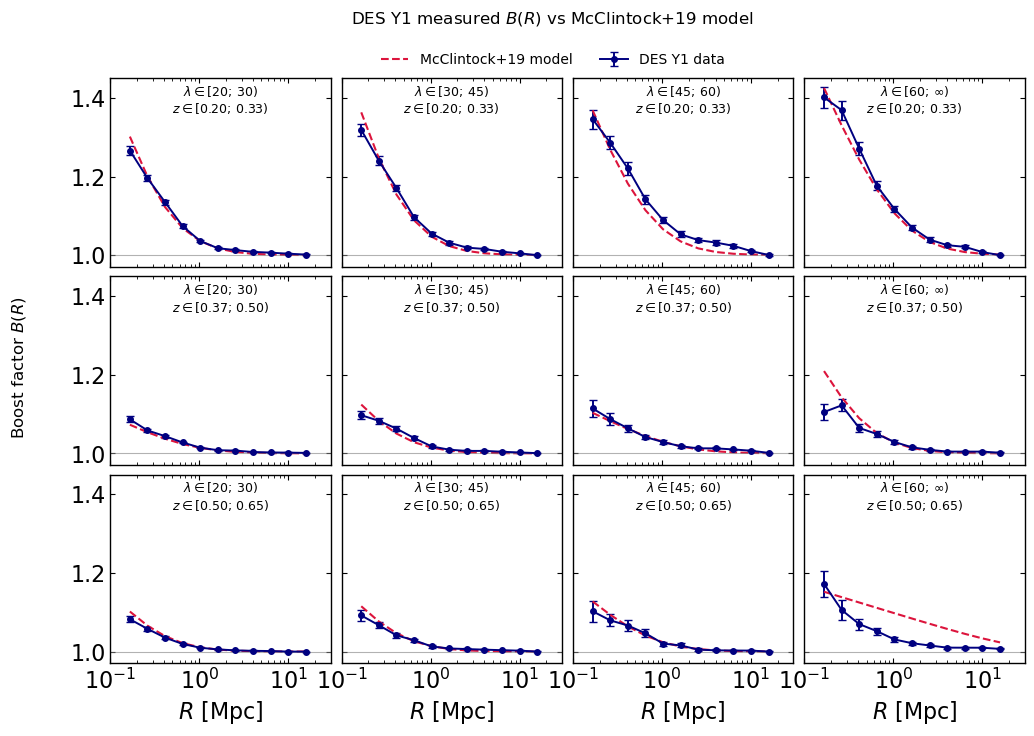

In [30]:
# === B(R) measured profiles per (lambda, z) bin ===========================
fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 2.8 + 0.6, nz * 2.4 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        # DES Y1 measured B(R) with error bars (data-driven)
        ax.errorbar(
            radii, B_data[il, iz],
            yerr=B_data_err[il, iz],
            fmt='o-', color='navy', ms=4, lw=1.4, capsize=3,
            label='DES Y1 data' if (iz == 0 and il == 0) else None,
        )
        # McClintock+19 parametric model (computed in §7.3 cell 42)
        ax.plot(
            radii, B_grid[il, iz], '--', color='crimson', lw=1.5,
            label='McClintock+19 model' if (iz == 0 and il == 0) else None,
        )
        ax.axhline(1.0, ls='-', color='gray', alpha=0.6, lw=0.8)
        ax.set_xscale('log')
        ax.set_ylim(0.97, 1.45)
        ax.set_xlim(1e-1, 3e1)
        lam_lo, lam_hi = LBDBINS[il], LBDBINS[il + 1]
        lam_hi_str = r'\infty' if lam_hi >= 500 else f'{int(lam_hi)}'
        label = (
            rf'$\lambda \in [{int(lam_lo)};\,{lam_hi_str})$' + '\n'
            rf'$z \in [{ZMIN_LIST[iz]:.2f};\,{ZMAX_LIST[iz]:.2f})$'
        )
        ax.text(
            0.5, 0.97, label,
            transform=ax.transAxes, fontsize=9, va='top', ha='center',
        )

for il in range(nl):
    axes[-1, il].set_xlabel(r'$R\ [{\rm Mpc}]$')
fig.text(
    0.04, 0.5, r'Boost factor $B(R)$',
    va='center', rotation='vertical', fontsize=12,
)

# Top-of-figure legend so it doesn't collide with per-panel bin labels.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.tight_layout()
fig.subplots_adjust(top=0.88)   # reserve the top 12% for title + legend
fig.suptitle('DES Y1 measured $B(R)$ vs McClintock+19 model',
             y=0.97, fontsize=12)

fig.legend(handles, labels, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 0.93), fontsize=10, frameon=False)

plt.show()

## 8. Lensing data vector — EMPIRICAL route (Heidi / mass-matched ratio)

**Binning quantity:** the catalog redMaPPer outputs $(\texttt{LAMBDA\_CHISQ}, \texttt{Z\_LAMBDA})$ — measured on the Buzzard photometric catalog, so they carry per-halo LSS information the C19 sampler does not.

**Selection bias:** built directly from the catalog as the ratio of the RM-selected stack to a $(\log M, z_\mathrm{true})$-matched random reference (Wu+2022 method iii / `stacked_profile_weighted_by_mass_redshift.py`):

$$
\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)
= \frac{\langle \Delta\Sigma(R) \rangle_{\lambda^\mathrm{RM}\text{-sel}}}
       {\langle \Delta\Sigma(R) \rangle_\mathrm{mass\text{-}matched}}.
$$

No fitting function, no $R\to 0$ extrapolation; both numerator and denominator come straight from `mock['DeltaSigma']`. Use this as a catalog-direct cross-check on the analytical $\mathcal{B}_\mathrm{C1}$ of §7.

In [31]:
# === Empirical B_sel: catalog redMaPPer-binned vs (logM, z)-matched random ===
from stacked_profile_weighted_by_mass_redshift import (
    stacked_profile_weighted_by_mass_redshift as mass_match_stack,
)




# --- Selected stacks on (LAMBDA_CHISQ, Z_LAMBDA) bins (DSigma + Sigma) ---
DSigma_selected, N_sel, sel_masks = stack_in_bins(
    lam_RM, z_RM, DSigma,    LBDBINS, ZMIN_LIST, ZMAX_LIST,
)
Sigma_selected,  _,    _         = stack_in_bins(
    lam_RM, z_RM, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- (logM, z)-matched random references per bin (DSigma + Sigma) -------
DSigma_random     = np.zeros_like(DSigma_selected)
Sigma_random      = np.zeros_like(Sigma_selected)
shear_data_vector = np.zeros_like(DSigma_selected)   # selected (RM) shear
shear_random      = np.zeros_like(DSigma_selected)   # mass-matched reference shear
B_sel_emp         = np.zeros_like(DSigma_selected)   # empirical B_sel(R)

for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = sel_masks[il][iz]
        if not m.any():
            continue

        DSigma_random[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], DSigma[m],
            logM_true,    z_true,    DSigma,
            dm=0.1, dz=0.05,
        )
        Sigma_random[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], Sigma_all[m],
            logM_true,    z_true,    Sigma_all,
            dm=0.1, dz=0.05,
        )

        z_rep     = float(np.mean(z_RM[m]))
        scinv_bin = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))
        shear_data_vector[il, iz] = DSigma_selected[il, iz] * scinv_bin
        shear_random[il, iz]      = DSigma_random  [il, iz] * scinv_bin

        with np.errstate(divide='ignore', invalid='ignore'):
            B_sel_emp[il, iz] = np.where(
                DSigma_random[il, iz] != 0.0,
                DSigma_selected[il, iz] / DSigma_random[il, iz],
                np.nan,
            )

print('Halos per (LAMBDA_CHISQ, Z_LAMBDA) bin:')
print(N_sel)

Halos per (LAMBDA_CHISQ, Z_LAMBDA) bin:
[[ 825 2474 2574]
 [ 182  626  554]
 [  36  123  113]
 [  38  113   90]]


### 8.1  Selection-bias ratio $\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)$ (with bootstrap error bands)

Wu+2022 Fig. 2 reproduction with bootstrap uncertainty: per $(\lambda^\mathrm{RM}, z^\mathrm{RM})$ bin, ratio of selected stack to mass-matched random for both $\Sigma$ (orange) and $\Delta\Sigma$ (blue). Bell-shaped peak around $R \sim 1$ Mpc is the LSS-environment-driven selection signal. The null test that follows replaces the RM binning with the C19 sampler — the ratio collapses to $\approx 1$ as expected (cross-check that the bell is not an artifact of the matching procedure).

In [34]:
# === Empirical B_sel(R) panel grid with bootstrap error bands ==============
# Bootstrap the per-bin ratio by resampling halos within each (lambda, z) bin
# and rebuilding the (logM, z)-matched random reference each time.
from itertools import product

N_BOOT  = 50            # 50 enough; 100+ gives smoother bands
DM_GRID = 0.1
DZ_GRID = 0.05
rng_boot = np.random.default_rng(seed=0)


def bootstrap_ratio_one_bin(idx_sel, profile, logM_arr, z_arr,
                            n_boot, dm, dz, rng):
    n_sel = idx_sel.size
    nr    = profile.shape[1]
    if n_sel == 0:
        return np.full(nr, np.nan), np.full(nr, np.nan)
    ratios = np.empty((n_boot, nr))
    for b in range(n_boot):
        idx_b    = rng.choice(idx_sel, size=n_sel, replace=True)
        sel_mean = profile[idx_b].mean(axis=0)
        rnd_mean = mass_match_stack(
            logM_arr[idx_b], z_arr[idx_b], profile[idx_b],
            logM_arr,        z_arr,        profile,
            dm=dm, dz=dz,
        )
        with np.errstate(divide='ignore', invalid='ignore'):
            ratios[b] = np.where(rnd_mean != 0, sel_mean / rnd_mean, np.nan)
    return np.nanmean(ratios, axis=0), np.nanstd(ratios, axis=0)


nl, nz, nr = DSigma_selected.shape
ratio_DSigma_mean = np.full((nl, nz, nr), np.nan)
ratio_DSigma_std  = np.full((nl, nz, nr), np.nan)
ratio_Sigma_mean  = np.full((nl, nz, nr), np.nan)
ratio_Sigma_std   = np.full((nl, nz, nr), np.nan)

In [ ]:
print('Running bootstrap (%d resamples per bin)...' % N_BOOT)
for il, iz in product(range(nl), range(nz)):
    idx_sel = np.where(sel_masks[il][iz])[0]
    if idx_sel.size == 0:
        continue
    ratio_DSigma_mean[il, iz], ratio_DSigma_std[il, iz] = bootstrap_ratio_one_bin(
        idx_sel, DSigma,    logM_true, z_true, N_BOOT, DM_GRID, DZ_GRID, rng_boot,
    )
    ratio_Sigma_mean[il, iz], ratio_Sigma_std[il, iz] = bootstrap_ratio_one_bin(
        idx_sel, Sigma_all, logM_true, z_true, N_BOOT, DM_GRID, DZ_GRID, rng_boot,
    )
    print(f'  lam bin {il}, z bin {iz}: N = {idx_sel.size:6d}')

# --- Plot: Wu+22 Fig. 2 with bootstrap bands -------------------------------
fig, axes = plt.subplots(
    nz, nl, figsize=(nl * 3.0 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        ax.fill_between(
            radii,
            ratio_DSigma_mean[il, iz] - ratio_DSigma_std[il, iz],
            ratio_DSigma_mean[il, iz] + ratio_DSigma_std[il, iz],
            color='royalblue', alpha=0.25, lw=0,
        )
        ax.semilogx(radii, ratio_DSigma_mean[il, iz], '-',
                    color='royalblue', lw=1.8,
                    label=r'$\Delta\Sigma$' if (iz == 0 and il == 0) else None)
        ax.fill_between(
            radii,
            ratio_Sigma_mean[il, iz] - ratio_Sigma_std[il, iz],
            ratio_Sigma_mean[il, iz] + ratio_Sigma_std[il, iz],
            color='darkorange', alpha=0.25, lw=0,
        )
        ax.semilogx(radii, ratio_Sigma_mean[il, iz], '-',
                    color='darkorange', lw=1.8,
                    label=r'$\Sigma$' if (iz == 0 and il == 0) else None)

        ax.axhline(1.0, ls='--', color='gray', alpha=0.7, lw=0.8)
        ax.set_ylim(0.85, 1.7)
        ax.text(
            0.04, 0.92,
            r'$%.2f \leq z^{\rm RM} < %.2f$    $%i \leq \lambda^{\rm RM} < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

for il in range(nl):
    axes[-1, il].set_xlabel(r'$r_p\ [{\rm pMpc}]$')
axes[nz // 2, 0].set_ylabel(r'observed / expected')
# Top-of-figure legend so it doesn't collide with per-panel bin labels.
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.tight_layout()
fig.subplots_adjust(top=0.88)   # reserve the top 12% for title + legend

fig.suptitle(
    r'Empirical $\mathcal{B}_{\rm sel}(R)$ with %d-sample bootstrap bands '
    r'(reproduces Wu+2022 Fig. 2)' % N_BOOT,
    y=0.97, fontsize=11,
)

fig.legend(
    handles, labels,
    loc='upper center',                  # anchor the TOP of the legend
    bbox_to_anchor=(0.5, 0.93),          # ...at y=0.93, below the title
    ncol=2, fontsize=10, frameon=False,
)

plt.show()

### Null test — same plot but binning on the C19 sampler

Replace the redMaPPer richness with our environment-blind `lambda_obs`. The selected/mass-matched ratio should collapse to ≈ 1 at all $R$, confirming that the bell-shaped signal above is genuinely LSS-driven and not an artifact of the matching procedure.

/tmp/ipykernel_2281977/3541204633.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


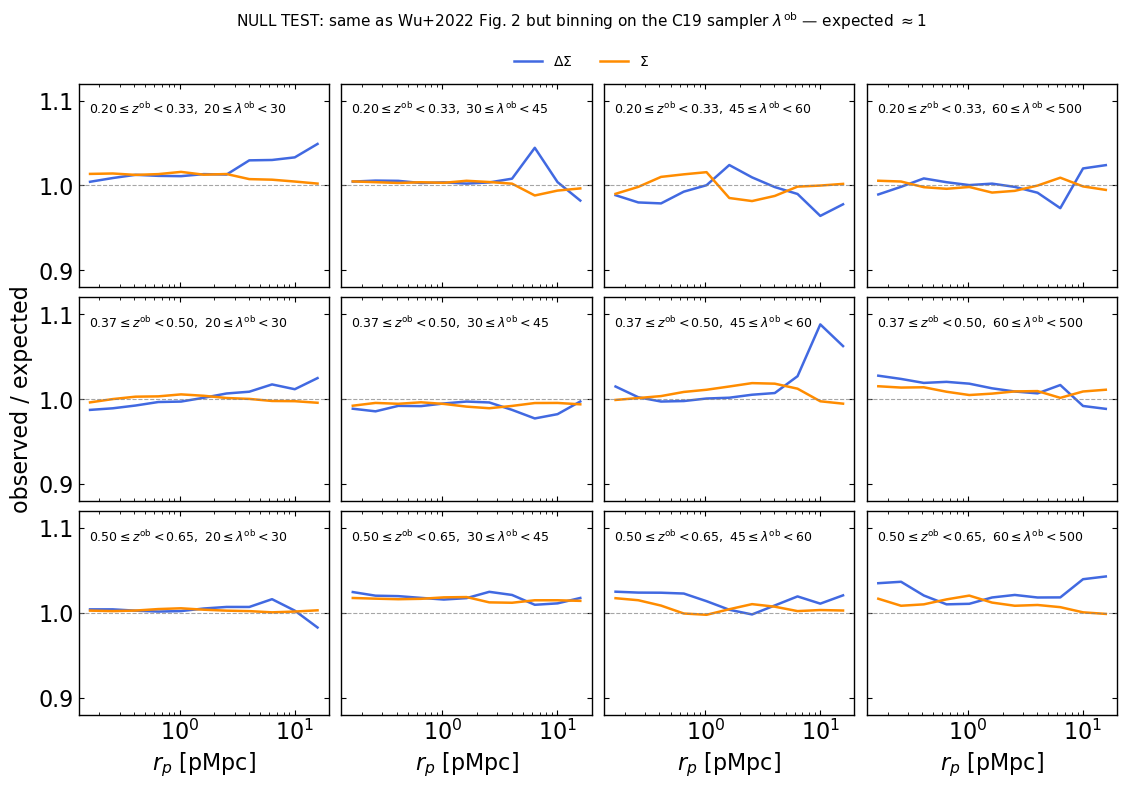

Median ratio per radial bin, averaged over (lambda, z):
  Sigma  : [1.005 1.004 1.006 1.007 1.006 1.005 1.006 1.005 1.002 1.    1.   ]
  DSigma : [1.004 1.005 1.007 1.003 1.003 1.005 1.007 1.008 1.017 1.011 1.019]


In [35]:
# === Same as the cell above, but binning the selected sample on the C19 ====
# forward-model lambda_obs (lob_arr, zob_arr) instead of the redMaPPer
# (LAMBDA_CHISQ, Z_LAMBDA). This ratio should be ~1 at all R because the
# C19 sampler doesn't carry per-halo LSS information -- a clean null test
# of the mass-matching procedure.

# --- Stack on (lambda_obs, z_obs) bins --------------------------------------
DSigma_selected_C19, _, c19_masks = stack_in_bins(
    lob_arr, zob_arr, DSigma, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)
Sigma_selected_C19, _, _ = stack_in_bins(
    lob_arr, zob_arr, Sigma_all, LBDBINS, ZMIN_LIST, ZMAX_LIST,
)

# --- (logM, z)-matched random references per bin -- using the C19 masks ----
DSigma_random_C19 = np.zeros_like(DSigma_selected_C19)
Sigma_random_C19  = np.zeros_like(Sigma_selected_C19)
for il in range(len(LBDBINS) - 1):
    for iz in range(len(ZMIN_LIST)):
        m = c19_masks[il][iz]
        if not m.any():
            continue
        DSigma_random_C19[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], DSigma[m],
            logM_true,    z_true,    DSigma,
            dm=0.1, dz=0.05,
        )
        Sigma_random_C19[il, iz] = mass_match_stack(
            logM_true[m], z_true[m], Sigma_all[m],
            logM_true,    z_true,    Sigma_all,
            dm=0.1, dz=0.05,
        )

# --- Ratios -----------------------------------------------------------------
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_Sigma_C19  = np.where(Sigma_random_C19  != 0,
                                Sigma_selected_C19  / Sigma_random_C19,  np.nan)
    ratio_DSigma_C19 = np.where(DSigma_random_C19 != 0,
                                DSigma_selected_C19 / DSigma_random_C19, np.nan)

# --- Plot: nz rows (redshift) x nl columns (richness) -----------------------
nl = len(LBDBINS) - 1
nz = len(ZMIN_LIST)

fig, axes = plt.subplots(
    nz, nl,
    figsize=(nl * 3.2 + 0.6, nz * 2.6 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        ax.semilogx(radii, ratio_DSigma_C19[il, iz], '-', color='royalblue',
                     lw=1.8, label=r'$\Delta\Sigma$' if (iz == 0 and il == 0) else None)
        ax.semilogx(radii, ratio_Sigma_C19 [il, iz], '-', color='darkorange',
                     lw=1.8, label=r'$\Sigma$'      if (iz == 0 and il == 0) else None)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.7, lw=0.8)

        ax.set_ylim(0.88, 1.12)
        ax.text(
            0.04, 0.92,
            r'$%.2f \leq z^{\rm ob} < %.2f,\ %i \leq \lambda^{\rm ob} < %i$'
            % (ZMIN_LIST[iz], ZMAX_LIST[iz], LBDBINS[il], LBDBINS[il + 1]),
            transform=ax.transAxes, fontsize=9, va='top',
        )

# Outer-axis labelling
for il in range(nl):
    axes[-1, il].set_xlabel(r'$r_p\ [{\rm pMpc}]$')
axes[nz // 2, 0].set_ylabel(r'observed / expected')

fig.tight_layout()
fig.subplots_adjust(top=0.88)   # reserve the top 12% for title + legend

fig.suptitle(
    r'NULL TEST: same as Wu+2022 Fig. 2 but binning on the C19 sampler '
    r'$\lambda^{\rm ob}$ — expected $\approx 1$',
    y=0.97, fontsize=11,
)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',                  # anchor the TOP of the legend
    bbox_to_anchor=(0.5, 0.93),          # ...at y=0.93, below the title
    ncol=2, fontsize=10, frameon=False,
)

plt.show()


# --- Quick numeric summary ---
print("Median ratio per radial bin, averaged over (lambda, z):")
print("  Sigma  :", np.round(np.nanmedian(
    ratio_Sigma_C19.reshape(-1, ratio_Sigma_C19.shape[-1]),  axis=0), 3))
print("  DSigma :", np.round(np.nanmedian(
    ratio_DSigma_C19.reshape(-1, ratio_DSigma_C19.shape[-1]), axis=0), 3))

### 8.2  Tangential shear: RM-selected vs mass-matched random

Per richness bin in the middle redshift slice, the absolute $|\langle\gamma_t(R)\rangle|$ for both stacks. The RM-selected curve sits above the mass-matched random by the factor $\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)$ shown in §8.1.

/tmp/ipykernel_2281977/2699790924.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


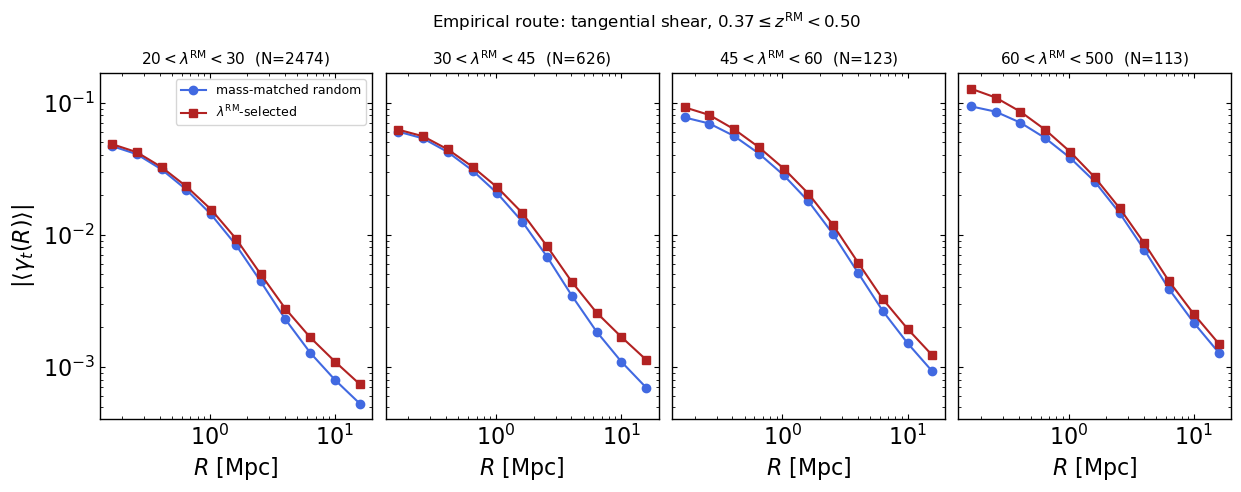

In [36]:
# --- Empirical route: per-bin tangential shear (RM-selected vs mass-matched) ---
nl = len(LBDBINS) - 1
zb = 1   # redshift bin to display

fig, axes = plt.subplots(
    1, nl, figsize=(nl * 3.4 + 1, 4.5),
    sharex=True, sharey=True,
    gridspec_kw={'wspace': 0.05},
)

for il in range(nl):
    ax = axes[il]
    s_sel = shear_data_vector[il, zb]   # RM-binned, no analytic correction
    s_rnd = shear_random[il, zb]        # (logM, z)-matched reference

    ax.loglog(radii, np.abs(s_rnd), 'o-', color='royalblue',
              label=r'mass-matched random')
    ax.loglog(radii, np.abs(s_sel), 's-', color='firebrick',
              label=r'$\lambda^{\rm RM}$-selected')
    ax.set_xlabel(r'$R\ [{\rm Mpc}]$')

    ax.set_title(
        r'$%i < \lambda^{\rm RM} < %i$  (N=%d)' %
        (LBDBINS[il], LBDBINS[il + 1], N_sel[il, zb]),
        fontsize=11,
    )
    if il > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r'$|\langle\gamma_t(R)\rangle|$')
axes[0].legend(loc='upper right', fontsize=9)

fig.suptitle(
    r'Empirical route: tangential shear, '
    r'$%.2f \leq z^{\rm RM} < %.2f$' % (ZMIN_LIST[zb], ZMAX_LIST[zb]),
    y=1.02, fontsize=12,
)
fig.tight_layout()
plt.show()

### 8.3  Shear data-vector covariance via spatial jackknife

$K = 50$ KMeans patches on (RA, DEC) — matches the DES Y1 convention used
in `createDataVector.ipynb` (which does the same via `treecorr.npatch=50`).
For each patch $k$, drop those halos and re-stack $\Delta\Sigma$ in each
$(\lambda, z)$ bin, convert to $\langle\gamma_t(R)\rangle$ with the bin-mean
$\Sigma_\mathrm{crit}^{-1}$, then compute the per-bin radial covariance

$$C^{ij}_{(\lambda, z)} = \frac{K-1}{K}\sum_{k=1}^{K}\bigl(\gamma_k^i - \bar\gamma^i\bigr)\bigl(\gamma_k^j - \bar\gamma^j\bigr).$$

Both primary stacks get covariances:
- `shear_C19_stack_cov` — analytical-route raw stack (no C1 boost applied)
- `shear_data_vector_cov` — empirical RM-selected stack

Output shape `(4, 3, 11, 11)` to match the `B_data_cov` convention.

In [37]:
# === Spatial jackknife patches via KMeans ================================
# BLAS thread caps live at the very top of the imports cell so that numpy /
# sklearn pick them up before any worker thread is spawned.
from sklearn.cluster import KMeans

K_JK = 50    # number of jackknife patches (matches Y1 / reference notebook)

ra_arr  = np.asarray(mock['RA'])
dec_arr = np.asarray(mock['DEC'])

# n_init=1 is enough — KMeans on (RA, DEC) is well-behaved enough to
# converge from a single k-means++ seed; 10 restarts (the sklearn default)
# would just multiply wall time and BLAS pressure.
_km = KMeans(n_clusters=K_JK, random_state=0, n_init=1, algorithm='lloyd')
patch_labels = _km.fit_predict(np.column_stack([ra_arr, dec_arr]))

_pop = np.bincount(patch_labels, minlength=K_JK)
print(f'K_JK = {K_JK}')
print(f'halos per patch:  min={_pop.min()},  median={int(np.median(_pop))},  max={_pop.max()}')

K_JK = 50
halos per patch:  min=5573,  median=12256,  max=16895


In [38]:
# === Per-bin shear covariance: jackknife over K_JK patches ===============
# Memory-efficient: iterate (il, iz) bins, mask halos directly, never build
# the full (N_halo, n_R) stack inside the loop.

shear_C19_stack_cov   = np.zeros((nl, nz, len(radii), len(radii)))
shear_data_vector_cov = np.zeros_like(shear_C19_stack_cov)

# Pre-bin masks so we only mask once per (il, iz) bin, not once per patch.
lob_bin_masks = [[(lob_arr >= LBDBINS[il]) & (lob_arr < LBDBINS[il + 1]) &
                  (zob_arr >= ZMIN_LIST[iz]) & (zob_arr < ZMAX_LIST[iz])
                  for iz in range(nz)] for il in range(nl)]
rm_bin_masks  = [[(lam_RM  >= LBDBINS[il]) & (lam_RM  < LBDBINS[il + 1]) &
                  (z_RM    >= ZMIN_LIST[iz]) & (z_RM    < ZMAX_LIST[iz])
                  for iz in range(nz)] for il in range(nl)]

# (K_JK, nl, nz, n_R) replicates per route — small, fits easily.
gC19_replicates = np.zeros((K_JK, nl, nz, len(radii)))
gRM_replicates  = np.zeros((K_JK, nl, nz, len(radii)))

for il in range(nl):
    for iz in range(nz):
        # ---- ANALYTICAL route, indices in this (il, iz) bin ----------------
        idx_c19_full = np.where(lob_bin_masks[il][iz])[0]
        if idx_c19_full.size == 0:
            pass
        else:
            DSigma_c19 = DSigma[idx_c19_full]                # (n_in_bin, n_R)
            patch_c19  = patch_labels[idx_c19_full]
            zob_c19    = zob_arr[idx_c19_full]
            for k in range(K_JK):
                in_jk = patch_c19 != k
                if in_jk.any():
                    z_rep = float(np.mean(zob_c19[in_jk]))
                    scinv = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))
                    gC19_replicates[k, il, iz] = DSigma_c19[in_jk].mean(axis=0) * scinv

        # ---- EMPIRICAL route ----------------------------------------------
        idx_rm_full = np.where(rm_bin_masks[il][iz])[0]
        if idx_rm_full.size == 0:
            continue
        DSigma_rm = DSigma[idx_rm_full]                      # (n_in_bin, n_R)
        patch_rm  = patch_labels[idx_rm_full]
        zRM_rm    = z_RM[idx_rm_full]
        for k in range(K_JK):
            in_jk = patch_rm != k
            if in_jk.any():
                z_rep = float(np.mean(zRM_rm[in_jk]))
                scinv = float(np.interp(z_rep, zlens, sigma_crit_inv_vec_z))
                gRM_replicates[k, il, iz] = DSigma_rm[in_jk].mean(axis=0) * scinv

# Per-(lambda, z) bin jackknife covariance
for il in range(nl):
    for iz in range(nz):
        gC19_mean = gC19_replicates[:, il, iz].mean(axis=0)
        gRM_mean  = gRM_replicates [:, il, iz].mean(axis=0)
        dC19 = gC19_replicates[:, il, iz] - gC19_mean
        dRM  = gRM_replicates [:, il, iz] - gRM_mean
        shear_C19_stack_cov  [il, iz] = (K_JK - 1) / K_JK * dC19.T @ dC19
        shear_data_vector_cov[il, iz] = (K_JK - 1) / K_JK * dRM.T  @ dRM

print(f'shear_C19_stack_cov shape:    {shear_C19_stack_cov.shape}')
print(f'shear_data_vector_cov shape:  {shear_data_vector_cov.shape}')
il, iz = 0, 0
print(f'\nbin (lambda={LBDBINS[il]}-{LBDBINS[il+1]}, z={ZMIN_LIST[iz]:.2f}-{ZMAX_LIST[iz]:.2f}):')
print(f'  C19 sigma_gamma_t: {np.sqrt(np.diag(shear_C19_stack_cov[il, iz]))}')
print(f'  RM  sigma_gamma_t: {np.sqrt(np.diag(shear_data_vector_cov[il, iz]))}')

shear_C19_stack_cov shape:    (4, 3, 11, 11)
shear_data_vector_cov shape:  (4, 3, 11, 11)

bin (lambda=20-30, z=0.20-0.33):
  C19 sigma_gamma_t: [4.77853264e-04 3.66713811e-04 2.69502125e-04 1.98540502e-04
 1.25234003e-04 7.94219810e-05 5.68881964e-05 3.75746698e-05
 2.48630264e-05 2.10289945e-05 1.70942253e-05]
  RM  sigma_gamma_t: [9.54726060e-04 7.95824730e-04 5.84810111e-04 3.75671752e-04
 2.54446233e-04 1.75252248e-04 1.07908663e-04 7.06748585e-05
 4.97179814e-05 3.88727043e-05 3.06489251e-05]


Correlation matrix of the empirical-route stack ($\Delta\Sigma$, RM-binned) per $(\lambda^\mathrm{RM}, z^\mathrm{RM})$ bin. Each panel is the
$11 \times 11$ radial correlation $C^{ij}/\sqrt{C^{ii} C^{jj}}$.

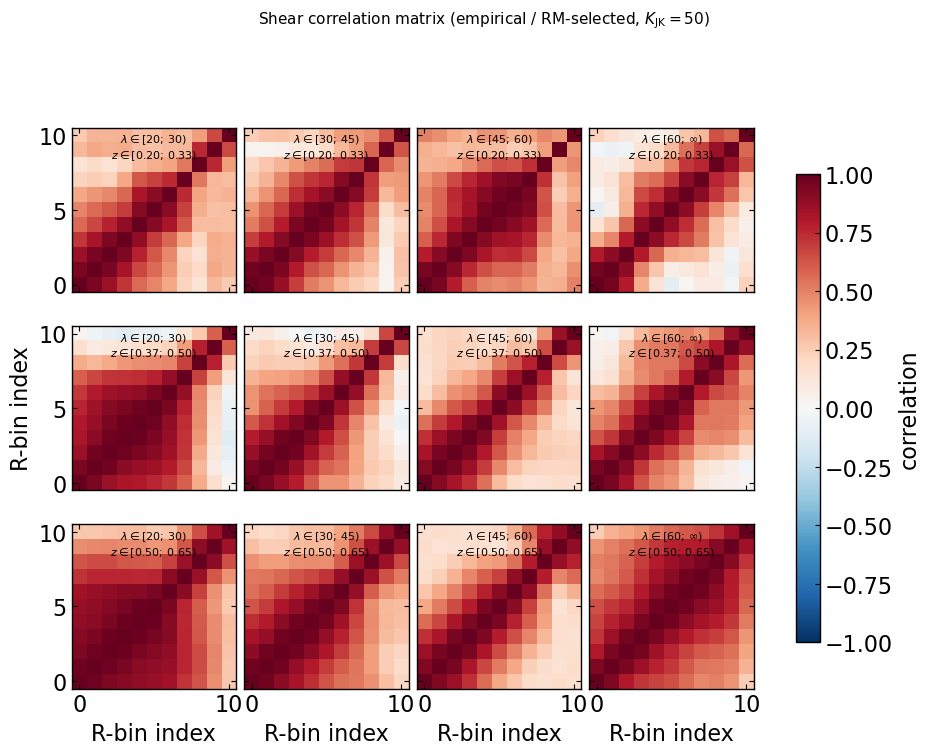

In [39]:
# === Diagnostic: shear correlation matrix per (lambda, z) bin =============
fig, axes = plt.subplots(
    nz, nl, figsize=(nl * 2.6 + 0.6, nz * 2.4 + 0.4),
    sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)
im = None
for iz in range(nz):
    for il in range(nl):
        ax = axes[iz, il]
        C = shear_data_vector_cov[il, iz]    # RM-route headline
        d = np.sqrt(np.abs(np.diag(C)))
        with np.errstate(divide='ignore', invalid='ignore'):
            corr = np.where(np.outer(d, d) > 0,
                            C / np.outer(d, d), np.nan)
        im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', origin='lower')
        lam_lo, lam_hi = LBDBINS[il], LBDBINS[il + 1]
        lam_hi_str = r'\infty' if lam_hi >= 500 else f'{int(lam_hi)}'
        label = (
            rf'$\lambda \in [{int(lam_lo)};\,{lam_hi_str})$' + '\n'
            rf'$z \in [{ZMIN_LIST[iz]:.2f};\,{ZMAX_LIST[iz]:.2f})$'
        )
        ax.text(0.5, 0.97, label, transform=ax.transAxes,
                fontsize=8, va='top', ha='center')
for il in range(nl):
    axes[-1, il].set_xlabel('R-bin index')
axes[nz // 2, 0].set_ylabel('R-bin index')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='correlation')
fig.suptitle(rf'Shear correlation matrix (empirical / RM-selected, $K_{{\rm JK}}={K_JK}$)',
             y=1.02, fontsize=11)
plt.show()

## 9. Save the data vector

Persist to the in-repo `output/` directory as a single `.npz` archive,
matching the save cell below.

**Bin metadata**

| key | shape | meaning |
|---|---|---|
| `radii_phys_mpc` | $(N_R,)$ | 11-point DES Y1 boost-factor R grid, physical Mpc |
| `lambda_bins` | $(N_\lambda + 1,)$ | richness bin edges |
| `z_bin_min`, `z_bin_max` | $(N_z,)$, $(N_z,)$ | redshift bin edges (seam-skipped) |

**Number counts** (DES Y1 expectation, Buzzard counts rescaled by $\Omega(z)$)

| key | shape | meaning |
|---|---|---|
| `NC` | $(N_\lambda, N_z)$ | $N(\lambda^\mathrm{ob}, z^\mathrm{ob})$ number counts |
| `NC_cov` | $(N_\lambda \cdot N_z, N_\lambda \cdot N_z)$ | diagonal Poisson covariance |

**Analytical route** (Matteo / C26 Eq.~C1, C19-binned)

| key | shape | meaning |
|---|---|---|
| `gamma_t_stack_C19` | $(N_\lambda, N_z, N_R)$ | stacked $\gamma_t$, no correction |
| `gamma_t_obs_C1` | $(N_\lambda, N_z, N_R)$ | $\gamma_t$ stack $\times\,\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}$ |
| `B_sel_C1` | $(N_\lambda, N_z, N_R)$ | analytical $\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}(R)$ |
| `shear_C19_stack_cov` | $(N_\lambda, N_z, N_R, N_R)$ | jackknife covariance of `gamma_t_stack_C19` (§8.3) |

**Empirical route** (Heidi / mass-matched, RM-binned)

| key | shape | meaning |
|---|---|---|
| `gamma_t_stack_RM` | $(N_\lambda, N_z, N_R)$ | $(\log M, z)$-matched random reference $\gamma_t$ |
| `gamma_t_obs_RM` | $(N_\lambda, N_z, N_R)$ | $\lambda^\mathrm{RM}$-selected stack $\gamma_t$ |
| `B_sel_emp` | $(N_\lambda, N_z, N_R)$ | empirical $\mathcal{B}_\mathrm{sel}^\mathrm{emp}(R)$ (bootstrap mean) |
| `shear_data_vector_cov` | $(N_\lambda, N_z, N_R, N_R)$ | jackknife covariance of `gamma_t_obs_RM` (§8.3) |

**DES Y1 measured boost factor + final mock-observed shears**

| key | shape | meaning |
|---|---|---|
| `B_data` | $(N_\lambda, N_z, N_R)$ | DES Y1 measured $B(R)$ |
| `B_data_err` | $(N_\lambda, N_z, N_R)$ | $1\sigma$ uncertainty on $B(R)$ |
| `B_data_cov` | $(N_\lambda, N_z, N_R, N_R)$ | full $11 \times 11$ covariance per bin |
| `gamma_t_mock_obs_C1` | $(N_\lambda, N_z, N_R)$ | analytical route $\times\,\mathcal{B}^{\Delta\Sigma}_\mathrm{C1}\,/\,B_\mathrm{data}$ |
| `gamma_t_mock_obs_RM` | $(N_\lambda, N_z, N_R)$ | empirical route $/\,B_\mathrm{data}$ |

Default shapes: $N_\lambda = 4$, $N_z = 3$, $N_R = 11$.

In [40]:
# === Save final data vector for downstream likelihood checks ============
out_dir  = os.path.join(os.getcwd(), 'output')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'MockDataVector.npz')

# Apply the DES Y1 boost-factor dilution to BOTH routes' shear stacks.
gamma_t_mock_obs_C1 = shear_C19_C1     / B_data    # analytical route + boost (Matteo)
gamma_t_mock_obs_RM = shear_data_vector / B_data   # empirical  route + boost (Heidi)

np.savez(
    out_path,
    # --- Bin metadata ---
    radii_phys_mpc=np.asarray(radii),         # 11-pt DES Y1 .dat grid (physical Mpc)
    lambda_bins=np.asarray(LBDBINS),
    z_bin_min=np.asarray(ZMIN_LIST),
    z_bin_max=np.asarray(ZMAX_LIST),

    # --- Number counts (DES Y1 expectation, Buzzard counts rescaled by Omega(z)) ---
    NC=NC_Y1,                                 # N(lambda_obs, z_obs)
    NC_cov=NC_cov,                            # (12, 12) diagonal Poisson covariance

    # --- ANALYTICAL route (Matteo / C26 Eq. C1, C19-binned) ---
    gamma_t_stack_C19=shear_C19_stack,        # stacked shear (no correction)
    gamma_t_obs_C1=shear_C19_C1,              # observed signal (stack * B_C1)
    B_sel_C1=Bsel_DSigma_C1,                  # analytical B_sel(R) for DSigma
    shear_C19_stack_cov=shear_C19_stack_cov,    # (4, 3, 11, 11) JK cov of analytical stack

    # --- EMPIRICAL route (Heidi / mass-matched, RM-binned) ---
    gamma_t_stack_RM=shear_random,            # mass-matched reference shear
    gamma_t_obs_RM=shear_data_vector,         # observed signal (RM-selected stack)
    B_sel_emp=ratio_DSigma_mean,              # empirical B_sel(R), bootstrap mean
    shear_data_vector_cov=shear_data_vector_cov,# (4, 3, 11, 11) JK cov of empirical stack

    # --- DES Y1 measured boost factor + final mock-observed shears -----
    B_data=B_data,                            # measured B(R), shape (4, 3, 11)
    B_data_err=B_data_err,                    # 1-sigma err on B(R)
    B_data_cov=B_data_cov,                    # full 11x11 cov per bin
    gamma_t_mock_obs_C1=gamma_t_mock_obs_C1,  # final shear: analytical (Matteo) + Y1 boost
    gamma_t_mock_obs_RM=gamma_t_mock_obs_RM,  # final shear: empirical (Heidi) + Y1 boost
)

print('Saved data vector to: %s' % out_path)
print('Keys:', list(np.load(out_path).keys()))

Saved data vector to: /global/u2/x/xintang/mocks/mock_cluster_buzzard/output/MockDataVector.npz
Keys: ['radii_phys_mpc', 'lambda_bins', 'z_bin_min', 'z_bin_max', 'NC', 'NC_cov', 'gamma_t_stack_C19', 'gamma_t_obs_C1', 'B_sel_C1', 'shear_C19_stack_cov', 'gamma_t_stack_RM', 'gamma_t_obs_RM', 'B_sel_emp', 'shear_data_vector_cov', 'B_data', 'B_data_err', 'B_data_cov', 'gamma_t_mock_obs_C1', 'gamma_t_mock_obs_RM']


In [41]:
from scipy.interpolate import interp1d

# Source R (from boost file), converted with h=0.70 (Buzzard; DeRose+2019 Table 1)
R_src = radii * 0.70                     # physical Mpc/h

# Target grid (physical Mpc/h; confirm this matches your source convention)
R_tgt = np.array([0.200, 0.286, 0.409, 0.585, 0.836,
                  1.196, 1.710, 2.445, 3.497, 5.000])

# Log-log cubic interpolation (γ_t > 0 in this range, so log is safe)
f = interp1d(np.log(R_src), np.log(gamma_t_mock_obs_C1),
             kind='cubic', bounds_error=True)
gamma_t_tgt = np.exp(f(np.log(R_tgt)))

Interpolated shape: (4, 3, 10)


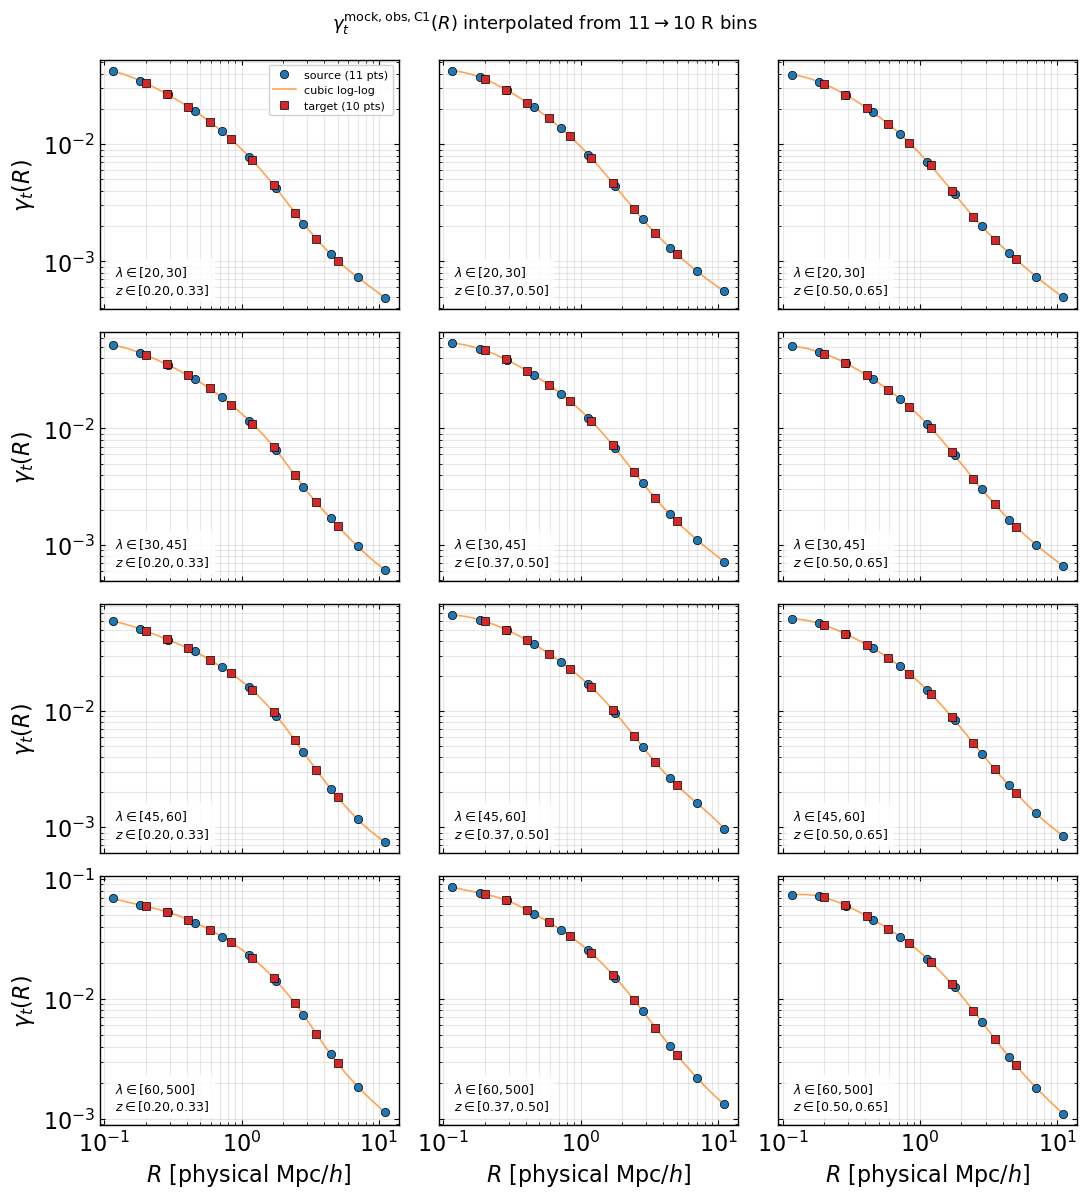

In [44]:
N_LAM, N_Z, N_R = 4, 3, 11
# ------------------------------------------------------------
# Interpolation: log-log cubic along the R (last) axis
# ------------------------------------------------------------
def loglog_interp(y_src, R_src, R_tgt, kind='cubic'):
    """
    Interpolate y_src (..., n_R_src) -> (..., n_R_tgt) in log-log.
 
    Wright & Brainerd 2000 (arXiv:astro-ph/9908213) Eqs. 11-16 give NFW DSigma(R)
    with smooth logarithmic slope varying in [-0.5, -2]; Seljak 2000
    (arXiv:astro-ph/0001493) Sec 5 gives the 2-halo term via Hankel transform
    of P_mm^lin, also smooth in log R. Cubic in (log R, log gamma_t) therefore
    has O((d log R)^4) error and no overshoot risk within [R_src.min, R_src.max].
    """
    logR_s, logR_t = np.log(R_src), np.log(R_tgt)
    orig = y_src.shape
    y_flat = y_src.reshape(-1, orig[-1])
    out = np.empty((y_flat.shape[0], len(R_tgt)))
    for i in range(y_flat.shape[0]):
        f = interp1d(logR_s, np.log(y_flat[i]), kind=kind, bounds_error=True)
        out[i] = np.exp(f(logR_t))
    return out.reshape(orig[:-1] + (len(R_tgt),))
 
gamma_t_tgt = loglog_interp(gamma_t_mock_obs_C1, R_src, R_tgt, kind='cubic')
print("Interpolated shape:", gamma_t_tgt.shape)
 
# ------------------------------------------------------------
# Plot: 4 (lambda) x 3 (z) grid of gamma_t vs R
# ------------------------------------------------------------
fig, axes = plt.subplots(N_LAM, N_Z, figsize=(11, 12),
                        sharex=True, sharey='row')
 
for il in range(N_LAM):
    for iz in range(N_Z):
        ax = axes[il, iz]
        ax.loglog(R_src, gamma_t_mock_obs_C1[il, iz], 'o', ms=6, color='C0',
                  mec='k', mew=0.5, label='source (11 pts)', zorder=4)
        # dense interp curve for eyeballing smoothness
        R_dense = np.logspace(np.log10(R_src[0])+1e-6,
                              np.log10(R_src[-1])-1e-6, 200)
        f = interp1d(np.log(R_src),
                     np.log(gamma_t_mock_obs_C1[il, iz]),
                     kind='cubic', bounds_error=True)
        ax.loglog(R_dense, np.exp(f(np.log(R_dense))), '-',
                  color='C1', lw=1.2, alpha=0.7, label='cubic log-log')
        ax.loglog(R_tgt, gamma_t_tgt[il, iz], 's', ms=6, color='C3',
                  mec='k', mew=0.5, label='target (10 pts)', zorder=5)
 
        # Annotations
        lam_lo, lam_hi = LBDBINS[il], LBDBINS[il+1]
        lam_str = f"$\\lambda \\in [{lam_lo},{lam_hi}]$" if lam_hi < 999 else f"$\\lambda \\geq {lam_lo}$"
        z_str = f"$z\\in [{ZMIN_LIST[iz]:.2f},{ZMAX_LIST[iz]:.2f}]$"
        ax.text(0.05, 0.05, f"{lam_str}\n{z_str}",
                transform=ax.transAxes, fontsize=9, va='bottom',
                bbox=dict(fc='white', ec='none', alpha=0.85))
        ax.grid(alpha=0.3, which='both')
        if il == 0 and iz == 0:
            ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
 
for ax in axes[-1, :]:
    ax.set_xlabel(r'$R$ [physical Mpc/$h$]')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\gamma_t(R)$')
 
fig.suptitle(r'$\gamma_t^{\rm mock,obs,C1}(R)$ interpolated from 11$\to$10 R bins',
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

In [46]:
# --- Save ------------------------------------------------------------------
out_dir  = os.path.join(os.getcwd(), 'output')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'MockDataVector_targetR.npz')
np.savez(
    out_path,
    radii_target_mpch   = R_tgt,                        # (10,)  physical Mpc/h
    lambda_bins         = np.asarray(LBDBINS),          # (5,)   edges — matches your original schema
    z_bin_min           = np.asarray(ZMIN_LIST),
    z_bin_max           = np.asarray(ZMAX_LIST),
    gamma_t_mock_obs_C1_10bin = gamma_t_tgt,      # (4, 3, 10)
)
print('Saved to:', out_path)
print('Keys:', list(np.load(out_path).keys()))

Saved to: /global/u2/x/xintang/mocks/mock_cluster_buzzard/output/MockDataVector_targetR.npz
Keys: ['radii_target_mpch', 'lambda_bins', 'z_bin_min', 'z_bin_max', 'gamma_t_mock_obs_C1_10bin']
